# 🎮 Gymnasium & Q-Learning — Teaching Agents by Trial and Error

> **What you'll learn:** the language of reinforcement learning (agent, state, action, reward, return, discount), Markov decision processes and the Bellman equations, how to *plan* in a known world with value and policy iteration, how to *learn* from experience with Monte Carlo, TD, Q-learning, and SARSA — and the Gymnasium API details (seeding, terminated vs truncated, wrappers, custom environments, honest evaluation) that separate working RL code from silently broken RL code.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🔴 Advanced (ramps up section by section) |
| **Time** | ~4 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [NumPy](../01_Core_Scientific_Computing/01_NumPy.ipynb) (arrays, `argmax`, random generators) · [ML Fundamentals From Scratch](../03_Classical_Machine_Learning/01_ML_Fundamentals_From_Scratch.ipynb) (learning rates, bias–variance) |
| **Tested with** | Python 3.12 · gymnasium 1.3 · numpy 2.5 · pandas 3.0 · scipy 1.18 · matplotlib |
| **Interview relevance** | ⭐⭐ Medium–High — "explain the Q-learning update", "on- vs off-policy", "SARSA vs Q-learning on CliffWalking", "exploration vs exploitation", "what is the Bellman equation", and the RL background behind RLHF questions |

## 🤔 What Is Reinforcement Learning?

Think about how you learned to ride a bike. Nobody gave you a dataset of "correct pedal pressures". You **tried** something, **wobbled or fell** (bad), **stayed upright a bit longer** (good), and slowly figured out what works. That is **reinforcement learning (RL)**: learning *what to do* from the **consequences** of your actions.

```
               action  aₜ
       ┌──────────────────────────┐
       │                          ▼
  ┌─────────┐               ┌─────────────┐
  │  AGENT  │               │ ENVIRONMENT │
  │ (policy)│               │ (the world) │
  └─────────┘               └─────────────┘
       ▲                          │
       └──────────────────────────┘
         next state sₜ₊₁, reward rₜ₊₁
```

| Term | Plain English | Bike example |
|---|---|---|
| **Agent** | the learner / decision maker | you |
| **Environment** | everything the agent interacts with | the bike, the road, gravity |
| **State** $s$ (or observation) | what the agent knows about the situation right now | speed, lean angle |
| **Action** $a$ | a choice the agent can make | steer left, steer right, pedal |
| **Reward** $r$ | a number saying how good the last step was | +1 for every second upright, −10 for falling |
| **Episode** | one attempt from start to finish | one ride until you stop or fall |
| **Return** $G$ | total (discounted) reward collected from now on | how long you stayed up in total |
| **Discount factor** $\gamma$ | how much future rewards count compared with immediate ones (0–1) | caring about the whole ride, not just the next second |
| **Policy** $\pi(a \mid s)$ | the agent's strategy: which action to take in each state | "if leaning left, steer left" |
| **Value** $V(s)$, **Q-value** $Q(s,a)$ | expected return from a state (or state + action) when following a policy | "from this lean angle, I'll probably stay up 30 more seconds" |

The agent's goal is to find a policy that **maximises the expected return**.

**Gymnasium** is the standard Python library that gives every RL problem the *same interface* — `reset()` to start an episode and `step(action)` to act — so the same agent code works on a balancing pole, a frozen lake, or a taxi. It is the maintained successor of OpenAI Gym, run by the Farama Foundation.

## 🎯 Why It Matters

- **LLMs are fine-tuned with RL.** RLHF (reinforcement learning from human feedback) uses PPO; newer reasoning models use GRPO. You can't follow those discussions without returns, values, policies, and on- vs off-policy learning — the ideas in this notebook.
- **Real products make sequential decisions.** Recommendation and ad bidding (often as *bandits*), robotics, game AI (AlphaGo), data-centre cooling, inventory and pricing all use RL ideas.
- **Silent bugs are the norm in RL.** A time-limit handled wrongly, a Q-table with tie-breaking bias, or an evaluation on a single lucky episode can make a broken agent look fine. This notebook shows each bug *with real numbers*.
- **In interviews** ML-engineer loops (especially at companies training LLMs, robotics, or recommender systems) ask you to *write the Q-learning update*, explain *exploration vs exploitation*, compare *SARSA and Q-learning*, define the *Bellman equation*, and explain why *terminated vs truncated* matters.

## ✅ By the End You Can

- [ ] Explain agent, environment, state, action, reward, return, and discount factor with an everyday example
- [ ] Write the Bellman expectation and optimality equations and solve a known MDP with value iteration and policy iteration
- [ ] Implement Monte Carlo, TD(0), Q-learning, and SARSA from scratch — and explain why Q-learning and SARSA walk different paths on CliffWalking
- [ ] Use the Gymnasium API correctly: `reset(seed=...)`, the 5-tuple from `step`, spaces, wrappers, and custom environments validated with `check_env`
- [ ] Explain why you bootstrap on **truncation** but not on **termination**, and prove it with an experiment
- [ ] Evaluate an agent honestly: greedy policy, many episodes, several seeds, mean ± std

## 📋 Table of Contents

1. [The Agent–Environment Loop in Gymnasium](#1.-The-Agent–Environment-Loop-in-Gymnasium-🟢)
2. [Spaces: What the Agent Sees and Does](#2.-Spaces:-What-the-Agent-Sees-and-Does-🟢)
3. [Rewards, Returns, and the Discount Factor](#3.-Rewards,-Returns,-and-the-Discount-Factor-🟢)
4. [MDPs and the Bellman Equations](#4.-MDPs-and-the-Bellman-Equations-🟡)
5. [Value Iteration and Policy Iteration](#5.-Value-Iteration-and-Policy-Iteration-🟡)
6. [Monte Carlo vs Temporal-Difference Learning](#6.-Monte-Carlo-vs-Temporal-Difference-Learning-🟡)
7. [Exploration: ε-Greedy and Decay Schedules](#7.-Exploration:-ε-Greedy-and-Decay-Schedules-🟢)
8. [Q-Learning: Off-Policy TD Control](#8.-Q-Learning:-Off-Policy-TD-Control-🟡)
9. [SARSA and CliffWalking: On- vs Off-Policy](#9.-SARSA-and-CliffWalking:-On--vs-Off-Policy-🟡)
10. [Wrappers: TimeLimit, RecordEpisodeStatistics, and Your Own](#10.-Wrappers:-TimeLimit,-RecordEpisodeStatistics,-and-Your-Own-🟡)
11. [Building and Validating a Custom Environment](#11.-Building-and-Validating-a-Custom-Environment-🟡)
12. [Terminated vs Truncated: When to Bootstrap](#12.-Terminated-vs-Truncated:-When-to-Bootstrap-🔴)
13. [Evaluating Agents Properly](#13.-Evaluating-Agents-Properly-🟡)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Q-Learning-vs-SARSA-on-Taxi) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel. Everything here runs on a CPU in a few minutes — the environments are tiny and the agents are NumPy tables.

The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "gymnasium>=1.0" "numpy>=2.0" "pandas>=2.2" scipy matplotlib

import sys
import time
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gymnasium import spaces
from gymnasium.utils.env_checker import check_env
from scipy import stats

print(f"Python {sys.version.split()[0]} | Gymnasium {gym.__version__} | NumPy {np.__version__} | pandas {pd.__version__}")

np.set_printoptions(precision=3, suppress=True)
OUTPUT_DIR = Path("_outputs")                 # files we write go here (ignored by git)
OUTPUT_DIR.mkdir(exist_ok=True)


def check(name, got, expected, hint=""):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    got_arr, exp_arr = np.asarray(got), np.asarray(expected)
    if got_arr.shape != exp_arr.shape:
        raise AssertionError(f"❌ {name}: shape {got_arr.shape}, expected {exp_arr.shape}. {hint}")
    numeric = np.issubdtype(exp_arr.dtype, np.number) and exp_arr.dtype != bool
    ok = np.allclose(got_arr, exp_arr, atol=1e-6) if numeric else np.array_equal(got_arr, exp_arr)
    assert ok, f"❌ {name}: values are not quite right. {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | Gymnasium 1.3.0 | NumPy 2.5.3 | pandas 3.0.5


## 1. The Agent–Environment Loop in Gymnasium 🟢

Every Gymnasium program has the same shape:

```python
env = gym.make("SomeEnv-v1")                 # build the world
obs, info = env.reset(seed=42)               # start an episode (seed once for reproducibility)
while True:
    action = policy(obs)                     # the agent decides
    obs, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:              # episode over → reset before stepping again
        break
```

`step` returns a **5-tuple**:

| Value | Meaning |
|---|---|
| `obs` | the next observation |
| `reward` | the reward for this step |
| `terminated` | the episode **really ended** inside the task (pole fell, reached the goal, fell in a hole) |
| `truncated` | the episode was **cut off from outside** (usually a time limit), even though the task could have continued |
| `info` | a dict of extra diagnostics |

(Old OpenAI Gym returned a single `done` flag. Splitting it into two matters for learning — Section 12 shows why.)

Our first environment is **CartPole**: push a cart left or right to keep a pole balanced. Reward is +1 for every step the pole stays up. Let's read its rules from the environment itself instead of trusting memory.

In [2]:
env = gym.make("CartPole-v1")
obs, info = env.reset(seed=42)

print("observation space:", env.observation_space)
print("action space     :", env.action_space, "→ 0 = push left, 1 = push right")
print("first observation:", obs, "= [cart position, cart velocity, pole angle (rad), pole angular velocity]")
print(f"time limit       : {env.spec.max_episode_steps} steps (then truncated=True)")
print(f"terminates when  : |pole angle| > {np.degrees(env.unwrapped.theta_threshold_radians):.0f}° "
      f"or |cart position| > {env.unwrapped.x_threshold}")

env.action_space.seed(42)                     # the action space has its own random generator
total_reward, n_steps = 0.0, 0
while True:
    action = env.action_space.sample()        # a random agent
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    n_steps += 1
    if terminated or truncated:
        break
print(f"\nrandom agent: {n_steps} steps, return {total_reward}, terminated={terminated}, truncated={truncated}")
env.close()

observation space: Box([-4.8     -inf -0.419   -inf], [4.8     inf 0.419   inf], (4,), float32)
action space     : Discrete(2) → 0 = push left, 1 = push right
first observation: [ 0.027 -0.006  0.036  0.02 ] = [cart position, cart velocity, pole angle (rad), pole angular velocity]
time limit       : 500 steps (then truncated=True)
terminates when  : |pole angle| > 12° or |cart position| > 2.4

random agent: 30 steps, return 30.0, terminated=True, truncated=False


A **policy** is just a function from observation to action. Let's compare a random policy with two hand-written rules over 100 episodes each — the kind of baseline you should always have before training anything.

In [3]:
def run_episodes(env, policy, n_episodes, seed):
    """Run `policy(obs) -> action` for n episodes; return the list of episode returns."""
    returns = []
    obs, _ = env.reset(seed=seed)                          # seed only the FIRST reset
    for episode in range(n_episodes):
        if episode > 0:
            obs, _ = env.reset()
        episode_return, done = 0.0, False
        while not done:
            obs, reward, terminated, truncated, _ = env.step(policy(obs))
            episode_return += reward
            done = terminated or truncated
        returns.append(episode_return)
    return np.array(returns)


cartpole = gym.make("CartPole-v1")
cartpole.action_space.seed(0)
policies = {
    "random": lambda o: cartpole.action_space.sample(),
    "push toward the lean (angle only)": lambda o: int(o[2] > 0),
    "angle + angular velocity": lambda o: int(o[2] + 0.5 * o[3] > 0),
}
for name, policy in policies.items():
    rets = run_episodes(cartpole, policy, n_episodes=100, seed=0)
    print(f"{name:34s} mean return {rets.mean():6.1f} ± {rets.std():5.1f}")

random                             mean return   21.6 ±  11.5
push toward the lean (angle only)  mean return   42.8 ±   8.9
angle + angular velocity           mean return  500.0 ±   0.0


A tiny change in the rule — also reacting to how fast the pole is falling — turns ~40 steps into the 500-step maximum. RL automates this search for good rules.

### ✍️ Your Turn

Reset `CartPole-v1` with `seed=0` and **always push right** (action `1`) until the episode ends. Store the number of steps in `n_steps_right`.

In [4]:
n_steps_right = None  # TODO: your code here
check("n_steps_right", n_steps_right, 8, hint="Loop: env.step(1) until terminated or truncated, counting steps.")

⏳ n_steps_right: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
env = gym.make("CartPole-v1")
env.reset(seed=0)
n_steps_right, done = 0, False
while not done:
    _, _, terminated, truncated, _ = env.step(1)
    n_steps_right += 1
    done = terminated or truncated
check("n_steps_right", n_steps_right, 8)
```

Pushing one way makes the pole fall the other way within a handful of steps — the episode **terminates** (not truncates).
</details>

> 💡 **Interview angle:** "What does `env.step` return in Gymnasium?" — `(obs, reward, terminated, truncated, info)`. Mention that `terminated` means a true terminal state of the task and `truncated` means an external cut-off such as a time limit — and that `reset` returns `(obs, info)`.

## 2. Spaces: What the Agent Sees and Does 🟢

A **space** describes the set of valid observations or actions. The type of space decides which algorithms you can use.

| Space | What it holds | Example environment |
|---|---|---|
| `Discrete(n)` | one integer in `0 … n-1` | FrozenLake state (16 cells), CartPole action (2) |
| `Box(low, high, shape)` | a real-valued array with bounds | CartPole observation (4 floats), Pendulum torque |
| `MultiDiscrete([n1, n2])` | several integers | a game controller with several buttons |
| `Dict({...})` / `Tuple((...))` | a structured combination | robot: camera image + joint angles |

In [5]:
for env_id in ["FrozenLake-v1", "Taxi-v4", "CliffWalking-v1", "CartPole-v1", "Pendulum-v1"]:
    e = gym.make(env_id)
    print(f"{env_id:16s} obs: {str(e.observation_space):45s} actions: {e.action_space}")
    e.close()

box = spaces.Box(low=-1.0, high=1.0, shape=(3,), dtype=np.float32)
box.seed(0)
sample = box.sample()
print("\nBox sample:", sample, "| contains it:", box.contains(sample),
      "| contains [2,0,0]:", box.contains(np.array([2, 0, 0], dtype=np.float32)))

taxi = gym.make("Taxi-v4")
state, _ = taxi.reset(seed=1)
taxi_row, taxi_col, passenger, destination = taxi.unwrapped.decode(state)
print(f"Taxi state {state} decodes to taxi at ({taxi_row},{taxi_col}), passenger location {passenger}, destination {destination}")

nested = spaces.Dict({"position": spaces.Box(0, 10, shape=(2,)), "has_key": spaces.Discrete(2)})
print("Dict space flattened size:", spaces.flatdim(nested))

FrozenLake-v1    obs: Discrete(16)                                  actions: Discrete(4)
Taxi-v4          obs: Discrete(500)                                 actions: Discrete(6)
CliffWalking-v1  obs: Discrete(48)                                  actions: Discrete(4)
CartPole-v1      obs: Box([-4.8     -inf -0.419   -inf], [4.8     inf 0.419   inf], (4,), float32) actions: Discrete(2)
Pendulum-v1      obs: Box([-1. -1. -8.], [1. 1. 8.], (3,), float32) actions: Box(-2.0, 2.0, (1,), float32)

Box sample: [ 0.274 -0.46  -0.918] | contains it: True | contains [2,0,0]: False
Taxi state 252 decodes to taxi at (2,2), passenger location 3, destination 0
Dict space flattened size: 4


> 💡 **Interview angle:** "How does the action space affect algorithm choice?" — tabular methods need small **discrete** state and action spaces; DQN needs **discrete actions** (it takes a max over them); SAC/TD3 are built for **continuous** (Box) actions; PPO handles both.

## 3. Rewards, Returns, and the Discount Factor 🟢

The agent doesn't maximise the *next* reward — it maximises the **return**, the sum of future rewards, with each step further away multiplied by one more factor of $\gamma$ (gamma):

$$G_t = r_{t+1} + \gamma\, r_{t+2} + \gamma^2 r_{t+3} + \dots = \sum_{k=0}^{\infty} \gamma^k\, r_{t+k+1}$$

**Why discount?**
1. **Math:** with $\gamma < 1$ an infinite sum of bounded rewards stays finite.
2. **Preference:** a reward now is worth more than the same reward later (like interest rates).
3. **Uncertainty:** you can read $\gamma$ as "the chance the world keeps going for another step".

A handy rule: the **effective horizon** is about $1 / (1 - \gamma)$ steps — $\gamma = 0.9$ looks ~10 steps ahead, $\gamma = 0.99$ ~100 steps.

In [6]:
def discounted_return(rewards, gamma):
    """G_0 = r_1 + γ r_2 + γ² r_3 + ... computed backwards in O(n)."""
    g = 0.0
    for r in reversed(rewards):
        g = r + gamma * g
    return g


snack_now = [1] + [0] * 20                   # +1 immediately
feast_later = [0] * 20 + [10]                # +10 after 20 steps
for gamma in [0.5, 0.9, 0.99]:
    a, b = discounted_return(snack_now, gamma), discounted_return(feast_later, gamma)
    choice = "snack now" if a > b else "feast later"
    print(f"γ={gamma:<4} horizon≈{1 / (1 - gamma):5.0f} steps | snack now={a:.3f}  feast later={b:.3f}  → prefers {choice}")

γ=0.5  horizon≈    2 steps | snack now=1.000  feast later=0.000  → prefers snack now
γ=0.9  horizon≈   10 steps | snack now=1.000  feast later=1.216  → prefers feast later
γ=0.99 horizon≈  100 steps | snack now=1.000  feast later=8.179  → prefers feast later


A small $\gamma$ makes the agent **short-sighted**; a large $\gamma$ makes it **patient** — but also makes returns noisier and learning slower, because rewards far in the future carry weight.

### ✍️ Your Turn

A taxi drives 3 steps (reward −1 each) and then drops off a passenger (+10). Compute the discounted return from the start with $\gamma = 0.9$ and store it in `taxi_return`.

In [7]:
taxi_rewards = [-1, -1, -1, 10]
taxi_return = None  # TODO: your code here
check("taxi_return", taxi_return, 4.58, hint="-1 + 0.9·(-1) + 0.9²·(-1) + 0.9³·10, or use discounted_return().")

⏳ taxi_return: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
taxi_rewards = [-1, -1, -1, 10]
taxi_return = discounted_return(taxi_rewards, 0.9)
check("taxi_return", taxi_return, 4.58)
```

$-1 - 0.9 - 0.81 + 7.29 = 4.58$. The +10 is worth only 7.29 today because it arrives three steps later.
</details>

> 💡 **Interview angle:** "What does the discount factor do?" — it trades off immediate vs future rewards, keeps infinite returns finite, and sets an effective horizon of about $1/(1-\gamma)$. It is **not** a learning rate.

## 4. MDPs and the Bellman Equations 🟡

A **Markov decision process (MDP)** is the formal model behind RL: a set of states, a set of actions, **transition probabilities** $p(s', r \mid s, a)$ (the chance of landing in $s'$ with reward $r$ after doing $a$ in $s$), and a discount $\gamma$. **Markov** means the next state depends only on the current state and action — not on the history.

**FrozenLake** is a perfect first MDP: walk from `S` to the goal `G` across a frozen lake without falling into holes `H`. On **slippery** ice you move in your intended direction only 1/3 of the time (and to each perpendicular side 1/3 of the time). Reward is 1 for reaching the goal, 0 otherwise.

Gymnasium exposes the true transition model as `env.unwrapped.P[state][action]` → a list of `(probability, next_state, reward, terminated)` tuples. Having the model is rare in practice, but it lets us compute *exact* answers and check the learning algorithms later.

In [8]:
lake = gym.make("FrozenLake-v1", is_slippery=True, render_mode="ansi")
lake.reset(seed=0)
print(lake.render())
P = lake.unwrapped.P
n_states, n_actions = lake.observation_space.n, lake.action_space.n
ACTION_NAMES = ["Left", "Down", "Right", "Up"]
print(f"{n_states} states, {n_actions} actions")
print("From state 14 (left of the goal), action Right:")
for prob, next_state, reward, terminated in P[14][2]:
    print(f"   p={prob:.3f} → state {next_state:2d}, reward {reward}, terminated={terminated}")


SFFF
FHFH
FFFH
HFFG

16 states, 4 actions
From state 14 (left of the goal), action Right:
   p=0.333 → state 14, reward 0, terminated=False
   p=0.333 → state 15, reward 1, terminated=True
   p=0.333 → state 10, reward 0, terminated=False


### The two Bellman equations

**Bellman expectation equation** — the value of a state under a fixed policy $\pi$ is the expected immediate reward plus the discounted value of where you land:

$$V^\pi(s) = \sum_a \pi(a \mid s) \sum_{s', r} p(s', r \mid s, a)\,\big[r + \gamma\, V^\pi(s')\big]$$

**Bellman optimality equation** — the best possible value picks the best action instead of averaging over the policy:

$$V^*(s) = \max_a \sum_{s', r} p(s', r \mid s, a)\,\big[r + \gamma\, V^*(s')\big], \qquad Q^*(s,a) = \sum_{s', r} p(s', r \mid s, a)\,\big[r + \gamma \max_{a'} Q^*(s', a')\big]$$

In plain English: *"how good is this spot = what I get now + how good the next spot is (discounted)"*. A terminal next state contributes no future value.

The expectation equation is a set of **linear** equations, so for a small MDP we can solve it two ways: repeatedly apply it until nothing changes (**iterative policy evaluation**), or solve $V = r_\pi + \gamma P_\pi V$ directly with linear algebra. They must agree.

In [9]:
GAMMA = 0.99


def policy_evaluation(P, policy_probs, gamma, theta=1e-10):
    """Iterative policy evaluation: sweep the Bellman expectation backup until values stop changing."""
    n_s, n_a = policy_probs.shape
    V = np.zeros(n_s)
    while True:
        delta = 0.0
        for s in range(n_s):
            v_new = sum(
                policy_probs[s, a] * sum(p * (r + gamma * V[s2] * (not term)) for p, s2, r, term in P[s][a])
                for a in range(n_a)
            )
            delta = max(delta, abs(v_new - V[s]))
            V[s] = v_new                                   # in-place update (converges faster)
        if delta < theta:
            return V


def policy_evaluation_exact(P, policy_probs, gamma):
    """Solve the linear system V = r_π + γ P_π V (no bootstrapping past terminal transitions)."""
    n_s, n_a = policy_probs.shape
    P_pi, r_pi = np.zeros((n_s, n_s)), np.zeros(n_s)
    for s in range(n_s):
        for a in range(n_a):
            for p, s2, r, term in P[s][a]:
                r_pi[s] += policy_probs[s, a] * p * r
                if not term:
                    P_pi[s, s2] += policy_probs[s, a] * p
    return np.linalg.solve(np.eye(n_s) - gamma * P_pi, r_pi)


random_policy = np.full((n_states, n_actions), 1 / n_actions)
V_random = policy_evaluation(P, random_policy, GAMMA)
V_random_exact = policy_evaluation_exact(P, random_policy, GAMMA)
assert np.allclose(V_random, V_random_exact, atol=1e-8)
print("V of the uniform random policy (iterative == exact ✅):\n", V_random.reshape(4, 4))

V of the uniform random policy (iterative == exact ✅):
 [[0.012 0.01  0.019 0.009]
 [0.015 0.    0.039 0.   ]
 [0.033 0.084 0.138 0.   ]
 [0.    0.17  0.434 0.   ]]


Even a random walker has a small chance of reaching the goal, and states next to the goal are worth the most.

### ✍️ Your Turn

A one-step Bellman backup by hand. From state `s` with $\gamma = 0.9$:
- **action 0:** reward 1, always lands in a state with value 10;
- **action 1:** with probability 0.5 reward 5 and the episode **terminates**; with probability 0.5 reward 0 and lands in a state with value 20.

Compute `q_values = [Q(s, 0), Q(s, 1)]`.

In [10]:
q_values = None  # TODO: your code here
check("q_values", q_values, [10.0, 11.5], hint="Q = Σ p·(r + γ·V(s')), and a terminal next state has V = 0.")

⏳ q_values: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
gamma = 0.9
q0 = 1.0 * (1 + gamma * 10)
q1 = 0.5 * (5 + gamma * 0) + 0.5 * (0 + gamma * 20)
q_values = [q0, q1]
check("q_values", q_values, [10.0, 11.5])
```

Action 1 is better (11.5 > 10) even though it gives no reward half the time — it's the *expected* return that counts.
</details>

> 💡 **Interview angle:** "What is the Bellman equation?" — a recursive definition of value: *value now = expected immediate reward + γ · value of the next state*. The **expectation** version evaluates a given policy (linear), the **optimality** version has a max and defines the best policy (non-linear).

## 5. Value Iteration and Policy Iteration 🟡

When the model $p(s', r \mid s, a)$ is known, you can **plan** — compute the optimal policy without any trial and error. This is called **dynamic programming**.

| Algorithm | Idea | Stops when |
|---|---|---|
| **Value iteration** | apply the Bellman *optimality* backup to every state, over and over | values change by less than θ |
| **Policy iteration** | alternate: **evaluate** the current policy exactly, then **improve** it by acting greedily on its values | the policy stops changing (always in a finite number of steps) |

In [11]:
def q_from_v(P, V, gamma, n_s, n_a):
    """One Bellman backup: Q(s,a) = Σ p · (r + γ V(s') · [not terminal])."""
    Q = np.zeros((n_s, n_a))
    for s in range(n_s):
        for a in range(n_a):
            Q[s, a] = sum(p * (r + gamma * V[s2] * (not term)) for p, s2, r, term in P[s][a])
    return Q


def value_iteration(P, n_s, n_a, gamma, theta=1e-10):
    V, deltas = np.zeros(n_s), []
    while True:
        Q = q_from_v(P, V, gamma, n_s, n_a)
        V_new = Q.max(axis=1)
        deltas.append(np.max(np.abs(V_new - V)))
        V = V_new
        if deltas[-1] < theta:
            return V, Q.argmax(axis=1), deltas


def policy_iteration(P, n_s, n_a, gamma):
    policy = np.zeros(n_s, dtype=int)                       # start with "always go Left"
    for iteration in range(1, 1000):
        V = policy_evaluation_exact(P, np.eye(n_a)[policy], gamma)          # 1) evaluate
        new_policy = q_from_v(P, V, gamma, n_s, n_a).argmax(axis=1)         # 2) improve greedily
        if np.array_equal(new_policy, policy):
            return V, policy, iteration
        policy = new_policy


start = time.perf_counter()
V_vi, policy_vi, deltas = value_iteration(P, n_states, n_actions, GAMMA)
vi_ms = (time.perf_counter() - start) * 1000
start = time.perf_counter()
V_pi, policy_pi, pi_iterations = policy_iteration(P, n_states, n_actions, GAMMA)
pi_ms = (time.perf_counter() - start) * 1000

print(f"value iteration : {len(deltas)} sweeps, {vi_ms:.0f} ms")
print(f"policy iteration: {pi_iterations} improvement steps, {pi_ms:.0f} ms")
assert np.allclose(V_vi, V_pi, atol=1e-6)
print("both reach the same optimal values ✅\nV*:\n", V_vi.reshape(4, 4))

value iteration : 571 sweeps, 28 ms
policy iteration: 7 improvement steps, 1 ms
both reach the same optimal values ✅
V*:
 [[0.542 0.499 0.471 0.457]
 [0.558 0.    0.358 0.   ]
 [0.592 0.643 0.615 0.   ]
 [0.    0.742 0.863 0.   ]]


Optimal policy on slippery FrozenLake:
← ↑ ↑ ↑
← H ← H
↑ ↓ ← H
H → ↓ G

success rate of the optimal policy over 2,000 episodes: 0.756  (V*(start) = 0.542)
random policy success rate: 0.013


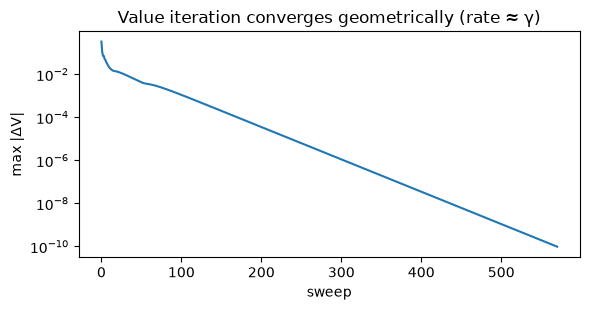

In [12]:
def show_policy(policy, desc, arrows="←↓→↑"):
    """Print a grid policy; holes (H) and goal (G) are shown as letters."""
    rows = []
    for r, row in enumerate(desc):
        cells = []
        for c, ch in enumerate(row):
            ch = ch.decode() if isinstance(ch, bytes) else ch
            cells.append(ch if ch in "HG" else arrows[policy[r * len(row) + c]])
        rows.append(" ".join(cells))
    print("\n".join(rows))


print("Optimal policy on slippery FrozenLake:")
show_policy(policy_vi, lake.unwrapped.desc)


def run_policy(env, policy, n_episodes, seed):
    """Returns of a table policy (array: state → action) over many episodes."""
    return run_episodes(env, lambda s: int(policy[s]), n_episodes, seed)


slippery = gym.make("FrozenLake-v1", is_slippery=True)
success_vi = run_policy(slippery, policy_vi, 2000, seed=123).mean()
print(f"\nsuccess rate of the optimal policy over 2,000 episodes: {success_vi:.3f}  (V*(start) = {V_vi[0]:.3f})")
print(f"random policy success rate: {run_episodes(slippery, lambda s: slippery.action_space.sample(), 2000, seed=123).mean():.3f}")

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(deltas)
ax.set(yscale="log", xlabel="sweep", ylabel="max |ΔV|", title="Value iteration converges geometrically (rate ≈ γ)")
plt.tight_layout()
plt.show()

Look at the policy: in several states the best move points **away** from the goal. On slippery ice, aiming at a wall means the two "slip" directions are the only risky ones — the planner discovered that without being told. The success rate is below 100% because the ice is random and episodes are cut off at 100 steps; $V^*(\text{start})$ is lower still because the reward is discounted.

> 💡 **Interview angle:** "Value iteration vs policy iteration?" — both are dynamic programming and need the model. Value iteration does cheap sweeps and converges asymptotically; policy iteration does expensive exact evaluations but converges in a handful of steps. Neither is possible when you *don't* know $p(s', r \mid s, a)$ — which is why we need learning.

## 6. Monte Carlo vs Temporal-Difference Learning 🟡

Without a model, we estimate values from **experience**. Two families:

| | **Monte Carlo (MC)** | **Temporal-Difference, TD(0)** |
|---|---|---|
| Update target | the actual return $G_t$ of the episode | $r_{t+1} + \gamma V(s_{t+1})$ — one real step + our current guess |
| When it updates | after the episode ends | after every step |
| Bias | **unbiased** (uses real returns) | **biased** (bootstraps on its own estimate) |
| Variance | **high** (a whole episode of randomness) | **low** (one step of randomness) |
| Needs episodes to end? | yes | no |

**Analogy:** predicting your commute time. MC waits until you arrive and uses the real total. TD updates on the way: "I'm at the bridge already after 10 minutes, and from the bridge it usually takes 15, so my new estimate is 25."

**Bootstrapping** = updating a guess using another guess. The TD update is
$V(s) \leftarrow V(s) + \alpha\,\big[r + \gamma V(s') - V(s)\big]$, where the bracket is the **TD error** and $\alpha$ is the learning rate.

Let's estimate the random policy's values on slippery FrozenLake with both methods and compare against the exact answer from Section 4.

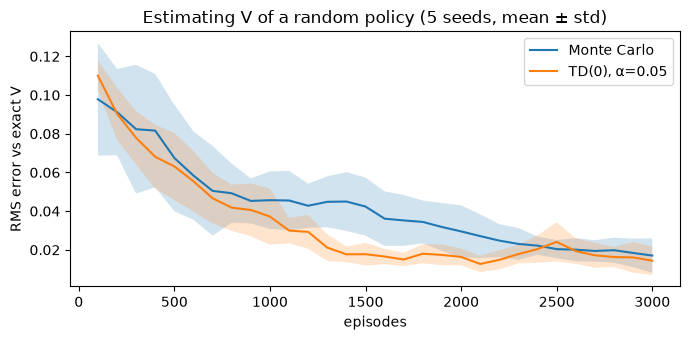

after   100 episodes: MC error 0.0978 | TD error 0.1100 → MC is closer
after  1000 episodes: MC error 0.0457 | TD error 0.0372 → TD is closer
after  3000 episodes: MC error 0.0170 | TD error 0.0144 → TD is closer
MC: average checkpoint-to-checkpoint change in error over the second half = 0.0014
TD: average checkpoint-to-checkpoint change in error over the second half = 0.0022


In [13]:
def mc_vs_td(n_episodes, seed, td_alpha=0.05, gamma=GAMMA, log_every=100):
    rng = np.random.default_rng(seed)
    env = gym.make("FrozenLake-v1", is_slippery=True, max_episode_steps=10_000)   # effectively no time limit
    V_mc, visits, V_td = np.zeros(n_states), np.zeros(n_states), np.zeros(n_states)
    errors = []
    state, _ = env.reset(seed=seed)
    for episode in range(n_episodes):
        if episode > 0:
            state, _ = env.reset()
        trajectory, done = [], False
        while not done:
            action = int(rng.integers(n_actions))                          # the random policy
            next_state, reward, terminated, truncated, _ = env.step(action)
            V_td[state] += td_alpha * (reward + gamma * V_td[next_state] * (not terminated) - V_td[state])  # TD(0)
            trajectory.append((state, reward))
            state, done = next_state, terminated or truncated
        g = 0.0
        for s, r in reversed(trajectory):                                   # Monte Carlo: real returns
            g = r + gamma * g
            visits[s] += 1
            V_mc[s] += (g - V_mc[s]) / visits[s]                            # running average (every-visit MC)
        if (episode + 1) % log_every == 0:
            rmse = lambda V: np.sqrt(np.mean((V - V_random_exact) ** 2))
            errors.append((episode + 1, rmse(V_mc), rmse(V_td)))
    return np.array(errors)


runs = np.stack([mc_vs_td(3000, seed) for seed in range(5)])               # (seeds, checkpoints, 3)
episodes_axis, mc_err, td_err = runs[0, :, 0], runs[:, :, 1], runs[:, :, 2]

fig, ax = plt.subplots(figsize=(7, 3.5))
for err, label in [(mc_err, "Monte Carlo"), (td_err, "TD(0), α=0.05")]:
    ax.plot(episodes_axis, err.mean(0), label=label)
    ax.fill_between(episodes_axis, err.mean(0) - err.std(0), err.mean(0) + err.std(0), alpha=0.2)
ax.set(xlabel="episodes", ylabel="RMS error vs exact V", title="Estimating V of a random policy (5 seeds, mean ± std)")
ax.legend()
plt.tight_layout()
plt.show()

for idx in [0, 9, len(episodes_axis) - 1]:                                 # after 100, 1,000 and 3,000 episodes
    mc_mean, td_mean = mc_err[:, idx].mean(), td_err[:, idx].mean()
    print(f"after {episodes_axis[idx]:5.0f} episodes: MC error {mc_mean:.4f} | TD error {td_mean:.4f} "
          f"→ {'TD' if td_mean < mc_mean else 'MC'} is closer")

second_half = len(episodes_axis) // 2
for name, err in [("MC", mc_err), ("TD", td_err)]:
    wiggle = np.abs(np.diff(err.mean(0)[second_half:])).mean()
    print(f"{name}: average checkpoint-to-checkpoint change in error over the second half = {wiggle:.4f}")

Read the plot and the numbers together:
- Both estimates approach the exact values, and on this problem the two end up in the same ballpark — which one is ahead depends on α, the number of episodes, and the environment (try `td_alpha=0.01` or `0.2`).
- MC's error curve is a **running average of real returns**, so it keeps shrinking smoothly as data accumulates.
- TD with a **constant** α never fully settles: every new transition nudges the estimate by the same fraction, so its error keeps wiggling. A decaying α (e.g. $1/N(s)$) removes that jitter.

### ✍️ Your Turn

Apply **one TD(0) update** by hand: $V(s) = 0.5$, reward $r = 1$, $V(s') = 2$, $\gamma = 0.9$, $\alpha = 0.1$, and the episode did **not** terminate. Store the new $V(s)$ in `v_new`.

In [14]:
v_new = None  # TODO: your code here
check("v_new", v_new, 0.73, hint="V(s) + α · (r + γ·V(s') − V(s))")

⏳ v_new: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
v_s, r, v_next, gamma, alpha = 0.5, 1.0, 2.0, 0.9, 0.1
td_error = r + gamma * v_next - v_s          # 1 + 1.8 - 0.5 = 2.3
v_new = v_s + alpha * td_error               # 0.5 + 0.23
check("v_new", v_new, 0.73)
```
</details>

> 💡 **Interview angle:** "MC vs TD?" — a bias–variance trade-off. MC is unbiased but high variance and needs complete episodes; TD bootstraps (biased) but has low variance, learns online, and works in continuing tasks. n-step returns and TD(λ)/GAE interpolate between them.

## 7. Exploration: ε-Greedy and Decay Schedules 🟢

**Exploration vs exploitation:** should you order your favourite dish (exploit what you know) or try something new that might be better (explore)? Never exploring means you may never find the best option; always exploring means you never cash in.

The simplest strategy is **ε-greedy**: with probability ε pick a random action, otherwise pick the action with the highest estimated value (breaking ties randomly).

The cleanest place to see the trade-off is a **multi-armed bandit** — an RL problem with a single state: 10 slot machines, each with an unknown average payout. Below, 2,000 independent bandit problems run *in parallel* with NumPy (synthetic data, because we need to know the true best arm to score the agent).

ε=0.0   last-100-step reward 1.022 | picks the best arm 35% of the time


ε=0.01  last-100-step reward 1.292 | picks the best arm 58% of the time


ε=0.1   last-100-step reward 1.367 | picks the best arm 80% of the time


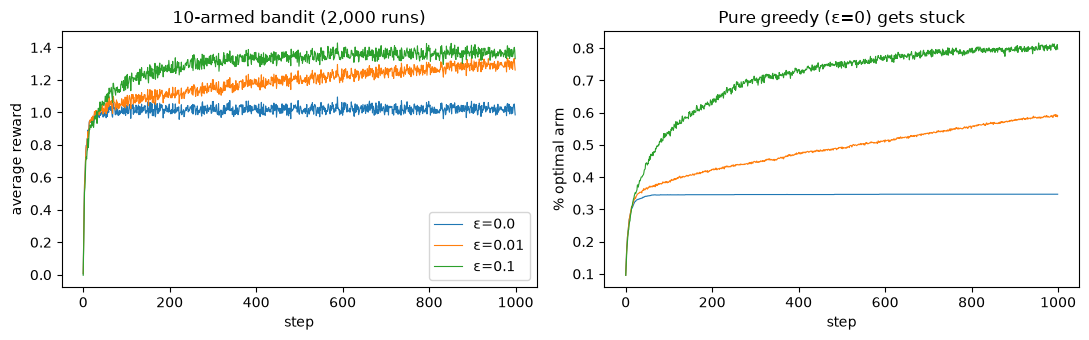

In [15]:
def run_bandits(epsilon, n_runs=2000, n_steps=1000, n_arms=10, seed=0):
    rng = np.random.default_rng(seed)
    true_means = rng.normal(size=(n_runs, n_arms))
    best_arm = true_means.argmax(axis=1)
    estimates, counts = np.zeros((n_runs, n_arms)), np.zeros((n_runs, n_arms))
    rows = np.arange(n_runs)
    avg_reward, pct_optimal = np.zeros(n_steps), np.zeros(n_steps)
    for t in range(n_steps):
        is_best = estimates == estimates.max(axis=1, keepdims=True)
        greedy = (is_best * rng.random((n_runs, n_arms))).argmax(axis=1)        # random tie-breaking
        explore = rng.random(n_runs) < epsilon
        arm = np.where(explore, rng.integers(0, n_arms, n_runs), greedy)
        reward = true_means[rows, arm] + rng.normal(size=n_runs)
        counts[rows, arm] += 1
        estimates[rows, arm] += (reward - estimates[rows, arm]) / counts[rows, arm]  # sample-average update
        avg_reward[t], pct_optimal[t] = reward.mean(), (arm == best_arm).mean()
    return avg_reward, pct_optimal


fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for eps in [0.0, 0.01, 0.1]:
    avg_reward, pct_optimal = run_bandits(eps)
    axes[0].plot(avg_reward, label=f"ε={eps}", lw=0.8)
    axes[1].plot(pct_optimal, label=f"ε={eps}", lw=0.8)
    print(f"ε={eps:<5} last-100-step reward {avg_reward[-100:].mean():.3f} | picks the best arm {pct_optimal[-100:].mean():.0%} of the time")
axes[0].set(xlabel="step", ylabel="average reward", title="10-armed bandit (2,000 runs)")
axes[1].set(xlabel="step", ylabel="% optimal arm", title="Pure greedy (ε=0) gets stuck")
axes[0].legend()
plt.tight_layout()
plt.show()

In full RL problems we usually **start exploratory and become greedy over time** with a decay schedule:

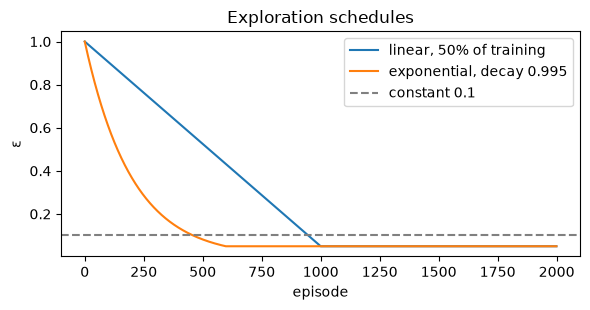

In [16]:
def linear_epsilon(episode, n_episodes, start=1.0, end=0.05, decay_fraction=0.5):
    """Linearly decay from `start` to `end` over the first `decay_fraction` of training, then stay at `end`."""
    progress = episode / max(1, decay_fraction * n_episodes)
    return max(end, start - (start - end) * progress)


def exponential_epsilon(episode, start=1.0, end=0.05, decay=0.995):
    return max(end, start * decay ** episode)


def epsilon_greedy(Q, state, epsilon, rng):
    """Random action with probability ε, otherwise a greedy action with RANDOM tie-breaking."""
    if rng.random() < epsilon:
        return int(rng.integers(Q.shape[1]))
    best = np.flatnonzero(Q[state] == Q[state].max())
    return int(rng.choice(best))


episodes = np.arange(2000)
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(episodes, [linear_epsilon(e, 2000) for e in episodes], label="linear, 50% of training")
ax.plot(episodes, [exponential_epsilon(e) for e in episodes], label="exponential, decay 0.995")
ax.axhline(0.1, ls="--", c="gray", label="constant 0.1")
ax.set(xlabel="episode", ylabel="ε", title="Exploration schedules")
ax.legend()
plt.tight_layout()
plt.show()

Other exploration strategies you should be able to name: **optimistic initial values** (start Q high so every action gets tried), **UCB** (bonus for rarely tried actions), **softmax/Boltzmann** (sample proportionally to $e^{Q/\tau}$), **Thompson sampling** (sample from a posterior), and in deep RL an **entropy bonus**.

### ✍️ Your Turn

With exponential decay (`start=1.0`, `decay=0.995`, `end=0.05`), what is ε at episode 500? Store it in `eps_500`.

In [17]:
eps_500 = None  # TODO: your code here
check("eps_500", eps_500, 0.0815718614, hint="max(end, start * decay ** episode)")

⏳ eps_500: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
eps_500 = exponential_epsilon(500, start=1.0, end=0.05, decay=0.995)   # = 0.995 ** 500
check("eps_500", eps_500, 0.0815718614)
```

$0.995^{500} = e^{500 \ln 0.995} \approx e^{-2.51} \approx 0.082$ — still above the 0.05 floor.
</details>

> 💡 **Interview angle:** "Explain exploration vs exploitation." — use the restaurant analogy, show ε-greedy, then name smarter options (UCB, Thompson sampling, entropy bonus). Point out that a greedy agent with **zero-initialised values and first-index tie-breaking** may never explore at all.

## 8. Q-Learning: Off-Policy TD Control 🟡

**Q-learning** learns the optimal action values $Q^*(s, a)$ directly from experience — no model needed. After every step $(s, a, r, s')$:

$$Q(s,a) \leftarrow Q(s,a) + \alpha\,\Big[\underbrace{r + \gamma \max_{a'} Q(s', a')}_{\text{TD target}} - Q(s,a)\Big]$$

(with no $\gamma \max Q$ term when $s'$ is terminal).

It is **off-policy**: the agent *behaves* ε-greedily (to explore) but the target uses the **max** — the value of acting *greedily* afterwards. So it learns about the greedy policy while following a different one. It converges to $Q^*$ if every state–action pair keeps being visited and the learning rate decays appropriately (Watkins & Dayan, 1992).

trained 5,000 episodes in 1.6 s
greedy Q-learning policy success: 0.756 | optimal (value iteration): 0.756
learned policy:
← ↑ ↑ ↑
← H → H
↑ ↓ ← H
H → ↓ G


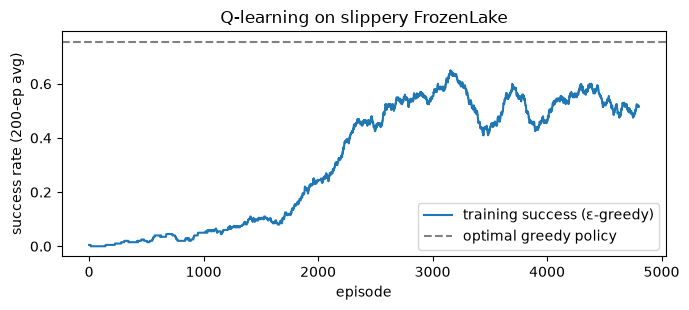

In [18]:
def q_learning(env, n_episodes, alpha=0.1, gamma=0.99, eps_start=1.0, eps_end=0.05, decay_fraction=0.5, seed=0):
    """Tabular Q-learning. Returns the Q-table and the undiscounted return of every training episode."""
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    episode_returns = np.zeros(n_episodes)
    state, _ = env.reset(seed=seed)
    for episode in range(n_episodes):
        if episode > 0:
            state, _ = env.reset()
        epsilon = linear_epsilon(episode, n_episodes, eps_start, eps_end, decay_fraction)
        done = False
        while not done:
            action = epsilon_greedy(Q, state, epsilon, rng)
            next_state, reward, terminated, truncated, _ = env.step(action)
            target = reward + gamma * Q[next_state].max() * (not terminated)    # bootstrap unless TRULY terminal
            Q[state, action] += alpha * (target - Q[state, action])
            episode_returns[episode] += reward
            state, done = next_state, terminated or truncated
    return Q, episode_returns


start = time.perf_counter()
Q_lake, lake_returns = q_learning(slippery, n_episodes=5000, alpha=0.1, gamma=GAMMA, seed=0)
print(f"trained 5,000 episodes in {time.perf_counter() - start:.1f} s")

policy_q = Q_lake.argmax(axis=1)
success_q = run_policy(slippery, policy_q, 2000, seed=123).mean()
print(f"greedy Q-learning policy success: {success_q:.3f} | optimal (value iteration): {success_vi:.3f}")
print("learned policy:")
show_policy(policy_q, lake.unwrapped.desc)

window = 200
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(np.convolve(lake_returns, np.ones(window) / window, mode="valid"), label="training success (ε-greedy)")
ax.axhline(success_vi, ls="--", c="gray", label="optimal greedy policy")
ax.set(xlabel="episode", ylabel=f"success rate ({window}-ep avg)", title="Q-learning on slippery FrozenLake")
ax.legend()
plt.tight_layout()
plt.show()

Q-learning got close to the planner's success rate **without ever seeing** `env.unwrapped.P`. Training success stays lower than the greedy policy's because the agent is still exploring (ε ≥ 0.05) — the reason you always evaluate greedily, separately (Section 13).

### ✍️ Your Turn

Apply **one Q-learning update**: $Q(s,a) = 2.0$, reward $r = -1$, $Q(s', \cdot) = [0, 5, 3]$, $\gamma = 0.9$, $\alpha = 0.5$, not terminal. Store the new $Q(s,a)$ in `q_new`.

In [19]:
q_new = None  # TODO: your code here
check("q_new", q_new, 2.75, hint="target = r + γ · max(Q[s']) = -1 + 0.9·5; then Q + α·(target − Q).")

⏳ q_new: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
q_sa, r, q_next, gamma, alpha = 2.0, -1.0, np.array([0.0, 5.0, 3.0]), 0.9, 0.5
target = r + gamma * q_next.max()          # 3.5
q_new = q_sa + alpha * (target - q_sa)     # 2.0 + 0.5 · 1.5
check("q_new", q_new, 2.75)
```
</details>

> 💡 **Interview angle:** "Write the Q-learning update and explain each term." — current estimate, TD target $r + \gamma \max_{a'} Q(s',a')$, TD error, learning rate. Say *why* it's off-policy (the max ignores what the behaviour policy will actually do) and mention *maximisation bias* → Double Q-learning.

## 9. SARSA and CliffWalking: On- vs Off-Policy 🟡

**SARSA** is named after the five things in its update: $(S, A, R, S', A')$. It uses the action the agent **will actually take** next — including exploratory ones:

$$Q(s,a) \leftarrow Q(s,a) + \alpha\,\big[r + \gamma\, Q(s', a') - Q(s,a)\big], \qquad a' \sim \varepsilon\text{-greedy}(Q, s')$$

So SARSA is **on-policy**: it learns the value of the policy it is following, exploration and all.

**CliffWalking** makes the difference visible. Walk from bottom-left `S` to bottom-right `G`. Every step costs −1; stepping into the **cliff** `C` costs −100 and sends you back to the start.

```
. . . . . . . . . . . .
. . . . . . . . . . . .
. . . . . . . . . . . .
S C C C C C C C C C C G
```

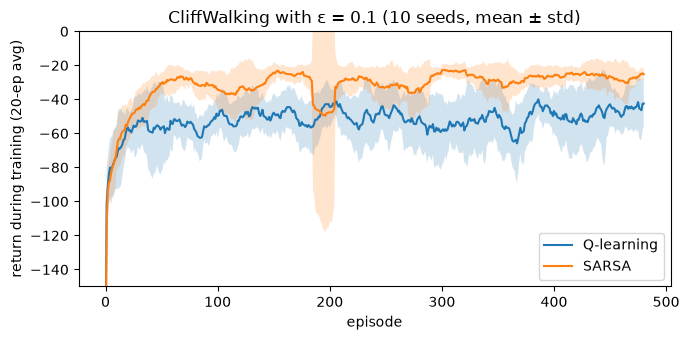

In [20]:
def sarsa(env, n_episodes, alpha=0.1, gamma=0.99, eps_start=1.0, eps_end=0.05, decay_fraction=0.5, seed=0):
    """Tabular SARSA (on-policy TD control). Same interface as q_learning()."""
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    episode_returns = np.zeros(n_episodes)
    state, _ = env.reset(seed=seed)
    for episode in range(n_episodes):
        if episode > 0:
            state, _ = env.reset()
        epsilon = linear_epsilon(episode, n_episodes, eps_start, eps_end, decay_fraction)
        action = epsilon_greedy(Q, state, epsilon, rng)
        done = False
        while not done:
            next_state, reward, terminated, truncated, _ = env.step(action)
            next_action = epsilon_greedy(Q, next_state, epsilon, rng)          # the action we WILL take
            target = reward + gamma * Q[next_state, next_action] * (not terminated)
            Q[state, action] += alpha * (target - Q[state, action])
            episode_returns[episode] += reward
            state, action, done = next_state, next_action, terminated or truncated
    return Q, episode_returns


cliff = gym.make("CliffWalking-v1")
CLIFF_SEEDS = range(10)
cliff_settings = dict(n_episodes=500, alpha=0.5, gamma=1.0, eps_start=0.1, eps_end=0.1)   # constant ε = 0.1
cliff_results = {"Q-learning": [], "SARSA": []}
for seed in CLIFF_SEEDS:
    cliff_results["Q-learning"].append(q_learning(cliff, seed=seed, **cliff_settings))
    cliff_results["SARSA"].append(sarsa(cliff, seed=seed, **cliff_settings))

fig, ax = plt.subplots(figsize=(7, 3.5))
for name, runs_ in cliff_results.items():
    curves = np.stack([np.convolve(r, np.ones(20) / 20, mode="valid") for _, r in runs_])
    ax.plot(curves.mean(0), label=name)
    ax.fill_between(np.arange(curves.shape[1]), curves.mean(0) - curves.std(0), curves.mean(0) + curves.std(0), alpha=0.2)
ax.set(ylim=(-150, 0), xlabel="episode", ylabel="return during training (20-ep avg)",
       title="CliffWalking with ε = 0.1 (10 seeds, mean ± std)")
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
def greedy_path(env, Q, max_steps=100):
    """Follow the greedy policy from the start; return visited states and the undiscounted return."""
    state, _ = env.reset(seed=0)
    path, total = [int(state)], 0.0
    for _ in range(max_steps):
        state, reward, terminated, truncated, _ = env.step(int(Q[state].argmax()))
        path.append(int(state))
        total += reward
        if terminated or truncated:
            break
    return path, total


def draw_cliff_path(path):
    grid = np.full((4, 12), ".")
    grid[3, 1:11] = "C"
    for s in path:
        grid[s // 12, s % 12] = "*"
    grid[3, 0], grid[3, 11] = "S", "G"
    return "\n".join(" ".join(row) for row in grid)


online, greedy_returns = {}, {}
for name, runs_ in cliff_results.items():
    online[name] = np.mean([r[-100:].mean() for _, r in runs_])
    greedy_returns[name] = [greedy_path(cliff, Q)[1] for Q, _ in runs_]
    path, ret = greedy_path(cliff, runs_[0][0])
    print(f"{name} (seed 0) greedy path — {len(path) - 1} steps, return {ret:.0f}:\n{draw_cliff_path(path)}\n")

for name in cliff_results:
    values, counts = np.unique(greedy_returns[name], return_counts=True)
    per_seed = ", ".join(f"{v:.0f} ×{c}" for v, c in zip(values, counts))
    looped = sum(r <= -100 for r in greedy_returns[name])
    print(f"{name:10s} | avg return while training (last 100 eps): {online[name]:7.1f} | "
          f"greedy return over {len(CLIFF_SEEDS)} seeds: {per_seed} | greedy policy stuck in a loop: {looped}")
safer = max(online, key=online.get)
shortest = {name: max(greedy_returns[name]) for name in greedy_returns}
print(f"\n→ {safer} collects more reward WHILE exploring; "
      f"best greedy path: Q-learning {-shortest['Q-learning']:.0f} steps vs SARSA {-shortest['SARSA']:.0f} steps.")

Q-learning (seed 0) greedy path — 13 steps, return -13:
. . . . . . . . . . . .
. . . . . . . . . . . .
* * * * * * * * * * * *
S C C C C C C C C C C G

SARSA (seed 0) greedy path — 17 steps, return -17:
* * * * * * * * * * * .
* . . . . . . . . . * *
* . . . . . . . . . . *
S C C C C C C C C C C G

Q-learning | avg return while training (last 100 eps):   -47.5 | greedy return over 10 seeds: -13 ×10 | greedy policy stuck in a loop: 0
SARSA      | avg return while training (last 100 eps):   -26.2 | greedy return over 10 seeds: -100 ×2, -19 ×2, -17 ×6 | greedy policy stuck in a loop: 2

→ SARSA collects more reward WHILE exploring; best greedy path: Q-learning 13 steps vs SARSA 17 steps.


**Why the paths differ:**
- **Q-learning** learns the value of the *greedy* policy, which walks right along the cliff edge (13 steps, the true optimum). But while it trains with ε = 0.1, random steps sometimes knock it off the cliff, so its **training** returns are worse.
- **SARSA** learns the value of the *ε-greedy* policy it actually follows. Near the cliff, "I might randomly step off" is baked into its Q-values, so it prefers the **safer, longer** path and earns more *while exploring*.
- If ε decays to 0, both converge to the optimal path. SARSA is what you'd want when mistakes during learning are costly (a real robot).
- A greedy policy read off an ε-greedy learner can occasionally **loop** in states it rarely visited (a "stuck" count above zero, return capped at −100). That is why evaluation episodes need a step cap — and why you evaluate several seeds.

### ✍️ Your Turn

Same transition as before: $r = -1$, $Q(s', \cdot) = [0, 5, 3]$, $\gamma = 0.9$. The ε-greedy policy happened to pick the **exploratory** action $a' = 2$ in $s'$. Compute `targets = [sarsa_target, q_learning_target]`.

In [22]:
targets = None  # TODO: your code here
check("targets", targets, [1.7, 3.5], hint="SARSA uses Q[s', a'] for the action actually chosen; Q-learning uses max Q[s'].")

⏳ targets: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
r, q_next, gamma, next_action = -1.0, np.array([0.0, 5.0, 3.0]), 0.9, 2
sarsa_target = r + gamma * q_next[next_action]     # -1 + 2.7
q_learning_target = r + gamma * q_next.max()       # -1 + 4.5
targets = [sarsa_target, q_learning_target]
check("targets", targets, [1.7, 3.5])
```
</details>

> 💡 **Interview angle:** "SARSA vs Q-learning on CliffWalking?" — Q-learning (off-policy) learns the optimal cliff-edge path but falls off more during ε-greedy training; SARSA (on-policy) accounts for its own exploration and learns the safer path with higher online reward. A common follow-up: *Expected SARSA* averages over the ε-greedy action probabilities instead of sampling $a'$.

## 10. Wrappers: TimeLimit, RecordEpisodeStatistics, and Your Own 🟡

A **wrapper** is an environment that contains another environment and changes one thing — the observation, the reward, the action, or the episode bookkeeping — without touching the original code. `gym.make` already stacks a few for you.

In [23]:
env = gym.make("CartPole-v1")
print("what gym.make built:", env)
print("the raw environment :", env.unwrapped)

stats_env = gym.wrappers.RecordEpisodeStatistics(gym.make("CartPole-v1"), buffer_length=50)
stats_env.action_space.seed(0)
obs, info = stats_env.reset(seed=0)
for _ in range(20):
    done = False
    while not done:
        obs, reward, terminated, truncated, info = stats_env.step(stats_env.action_space.sample())
        done = terminated or truncated
    last_info = info
    stats_env.reset()
print("\ninfo at the end of an episode:", last_info)
print(f"mean return of last {len(stats_env.return_queue)} episodes: {np.mean(stats_env.return_queue):.1f}")

what gym.make built: <TimeLimit<OrderEnforcing<PassiveEnvChecker<CartPoleEnv<CartPole-v1>>>>>
the raw environment : <CartPoleEnv<CartPole-v1>>

info at the end of an episode: {'episode': {'r': 19.0, 'l': 19, 't': 0.000105}}
mean return of last 20 episodes: 21.1


**TimeLimit** truncates episodes after a fixed number of steps. CliffWalking has **no time limit by default**, so a bad policy can wander for a very long time:

In [24]:
def random_episode_lengths(env, n_episodes, seed):
    env.action_space.seed(seed)
    lengths, truncations = [], 0
    env.reset(seed=seed)
    for _ in range(n_episodes):
        steps, done = 0, False
        while not done:
            _, _, terminated, truncated, _ = env.step(env.action_space.sample())
            steps += 1
            done = terminated or truncated
        lengths.append(steps)
        truncations += truncated
        env.reset()
    return np.array(lengths), truncations


print("CliffWalking spec max_episode_steps:", gym.make("CliffWalking-v1").spec.max_episode_steps)
lengths, n_trunc = random_episode_lengths(gym.make("CliffWalking-v1"), 20, seed=0)
print(f"random policy, no limit : mean length {lengths.mean():,.0f}, max {lengths.max():,}")
lengths, n_trunc = random_episode_lengths(gym.wrappers.TimeLimit(gym.make("CliffWalking-v1"), max_episode_steps=200), 20, seed=0)
print(f"with TimeLimit(200)     : mean length {lengths.mean():,.0f}, {n_trunc}/20 episodes truncated")

CliffWalking spec max_episode_steps: None


random policy, no limit : mean length 6,264, max 23,300
with TimeLimit(200)     : mean length 200, 19/20 episodes truncated


**Writing your own wrapper.** Subclass `gym.ObservationWrapper` (override `observation`), `gym.RewardWrapper` (override `reward`), `gym.ActionWrapper` (override `action`), or plain `gym.Wrapper` (override `step`/`reset`). Here's one you'll actually need: neural networks can't eat a state *number* like `14`, so we convert FrozenLake's `Discrete(16)` state into a **one-hot vector**.

In [25]:
class OneHotObservation(gym.ObservationWrapper):
    """Discrete(n) state → float32 one-hot vector of length n (so a neural network can consume it)."""

    def __init__(self, env):
        super().__init__(env)
        self.n = env.observation_space.n
        self.observation_space = spaces.Box(0.0, 1.0, shape=(self.n,), dtype=np.float32)

    def observation(self, observation):
        one_hot = np.zeros(self.n, dtype=np.float32)
        one_hot[observation] = 1.0
        return one_hot


onehot_lake = OneHotObservation(gym.make("FrozenLake-v1"))
obs, _ = onehot_lake.reset(seed=0)
print("observation space:", onehot_lake.observation_space)
print("start observation:", obs, "| inside the space:", onehot_lake.observation_space.contains(obs))

observation space: Box(0.0, 1.0, (16,), float32)
start observation: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] | inside the space: True


Built-in wrappers worth knowing (Gymnasium 1.x names): `TimeLimit`, `RecordEpisodeStatistics`, `RecordVideo`, `NormalizeObservation`, `NormalizeReward`, `ClipReward`, `TransformObservation`, `TransformReward`, `FlattenObservation`, `ResizeObservation`, `GrayscaleObservation`, `FrameStackObservation` (called `FrameStack` in older Gym code), and `AtariPreprocessing`.

### ✍️ Your Turn

Write a `ScaleReward` reward wrapper that multiplies every reward by `scale`. Wrap `CliffWalking-v1` with `scale=0.01`, reset with `seed=0`, step **right** (action `1`) straight into the cliff, and store the reward you receive in `scaled_reward`.

In [26]:
scaled_reward = None  # TODO: your code here
check("scaled_reward", scaled_reward, -1.0, hint="class ScaleReward(gym.RewardWrapper) with def reward(self, reward): return reward * self.scale")

⏳ scaled_reward: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
class ScaleReward(gym.RewardWrapper):
    def __init__(self, env, scale):
        super().__init__(env)
        self.scale = scale

    def reward(self, reward):
        return reward * self.scale


scaled_cliff = ScaleReward(gym.make("CliffWalking-v1"), scale=0.01)
scaled_cliff.reset(seed=0)
_, scaled_reward, _, _, _ = scaled_cliff.step(1)     # the cliff gives -100 → -1.0
check("scaled_reward", scaled_reward, -1.0)
```
</details>

> 💡 **Interview angle:** "How would you add frame stacking / reward normalisation / a time limit without editing the environment?" — wrappers. Know the difference between `ObservationWrapper`, `RewardWrapper`, `ActionWrapper`, and a full `Wrapper`, and that the *order* of wrappers matters (e.g. normalise before or after clipping).

## 11. Building and Validating a Custom Environment 🟡

To apply RL to *your* problem you write an environment class. The contract:

1. In `__init__`, define `self.observation_space` and `self.action_space`.
2. `reset(self, *, seed=None, options=None)` must call `super().reset(seed=seed)` (this seeds `self.np_random`) and return `(obs, info)`.
3. `step(self, action)` returns `(obs, reward, terminated, truncated, info)`.
4. Optional `render()`; declare `metadata = {"render_modes": [...], "render_fps": ...}`.
5. Validate with `gymnasium.utils.env_checker.check_env`, then `gym.register` it so `gym.make` can add a `TimeLimit`.

Our example: a 5×5 treasure hunt. The agent starts in a random free cell, the treasure `T` gives +1, the pit `P` gives −1 (both end the episode), and each step costs −0.01 so shorter routes are better.

In [27]:
class TreasureGridEnv(gym.Env):
    metadata = {"render_modes": ["ansi"], "render_fps": 4}
    SIZE, TREASURE, PIT = 5, (0, 4), (1, 3)
    MOVES = np.array([[0, -1], [1, 0], [0, 1], [-1, 0]])        # Left, Down, Right, Up (same order as FrozenLake)

    def __init__(self, render_mode=None):
        self.observation_space = spaces.Discrete(self.SIZE * self.SIZE)
        self.action_space = spaces.Discrete(4)
        self.render_mode = render_mode
        self._pos = np.array([self.SIZE - 1, 0])

    def _obs(self):
        return int(self._pos[0] * self.SIZE + self._pos[1])

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)                                   # seeds self.np_random
        while True:
            self._pos = self.np_random.integers(0, self.SIZE, size=2)
            if tuple(self._pos) not in (self.TREASURE, self.PIT):
                return self._obs(), {}

    def step(self, action):
        self._pos = np.clip(self._pos + self.MOVES[action], 0, self.SIZE - 1)
        cell = tuple(int(x) for x in self._pos)
        terminated = cell in (self.TREASURE, self.PIT)
        reward = 1.0 if cell == self.TREASURE else -1.0 if cell == self.PIT else -0.01
        return self._obs(), reward, terminated, False, {}           # time limits come from a wrapper, not here

    def render(self):
        grid = np.full((self.SIZE, self.SIZE), ".")
        grid[self.TREASURE], grid[self.PIT] = "T", "P"
        grid[tuple(self._pos)] = "A"
        return "\n".join(" ".join(row) for row in grid)


# raises if the API contract is broken; the render check is skipped only because it needs a registered spec
check_env(TreasureGridEnv(render_mode="ansi"), skip_render_check=True)
print("check_env passed ✅")

gym.register(id="TreasureGrid-v0", entry_point=TreasureGridEnv, max_episode_steps=50)
treasure = gym.make("TreasureGrid-v0", render_mode="ansi")
obs, _ = treasure.reset(seed=3)
print(f"registered env: {treasure}\nstart state {obs}:\n{treasure.render()}")

check_env passed ✅
registered env: <TimeLimit<OrderEnforcing<PassiveEnvChecker<TreasureGridEnv<TreasureGrid-v0>>>>>
start state 20:
. . . . T
. . . P .
. . . . .
. . . . .
A . . . .


`check_env` catches real mistakes. Here are two broken environments — an observation outside its declared space, and a `reset` that forgets to seed:

In [28]:
class ObsOutOfBounds(gym.Env):
    observation_space = spaces.Box(0.0, 1.0, shape=(2,), dtype=np.float32)
    action_space = spaces.Discrete(2)

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        return np.array([0.5, 2.0], dtype=np.float32), {}           # 2.0 is outside [0, 1]

    def step(self, action):
        return np.array([0.5, 0.5], dtype=np.float32), 0.0, False, False, {}


class ForgetsToSeed(gym.Env):
    observation_space = spaces.Discrete(3)
    action_space = spaces.Discrete(2)

    def reset(self, *, seed=None, options=None):                    # never calls super().reset(seed=seed)
        return 0, {}

    def step(self, action):
        return 1, 0.0, False, False, {}


for broken in [ObsOutOfBounds(), ForgetsToSeed()]:
    try:
        check_env(broken, skip_render_check=True)
        print(f"{type(broken).__name__}: passed (unexpected)")
    except AssertionError as err:
        print(f"❌ {type(broken).__name__}: {err}")

❌ ObsOutOfBounds: The first element returned by `env.reset()` is not within the observation space.
❌ ForgetsToSeed: Expects the random number generator to have been generated given a seed was passed to reset. Most likely the environment reset function does not call `super().reset(seed=seed)`.


Because our environment follows the contract, the Q-learning function from Section 8 works on it unchanged:

In [29]:
Q_treasure, treasure_returns = q_learning(gym.make("TreasureGrid-v0"), n_episodes=1500, alpha=0.5, gamma=0.99, seed=0)
demo = gym.make("TreasureGrid-v0", render_mode="ansi")
state, _ = demo.reset(seed=11)
print("start:\n" + demo.render())
done, n_moves, total = False, 0, 0.0
while not done:
    state, reward, terminated, truncated, _ = demo.step(int(Q_treasure[state].argmax()))
    n_moves, total, done = n_moves + 1, total + reward, terminated or truncated
print(f"\ngreedy agent finished in {n_moves} moves with return {total:.2f} (terminated={terminated}):\n{demo.render()}")

start:
A . . . T
. . . P .
. . . . .
. . . . .
. . . . .

greedy agent finished in 4 moves with return 0.97 (terminated=True):
. . . . A
. . . P .
. . . . .
. . . . .
. . . . .


> 💡 **Interview angle:** "How would you frame *your* business problem as an RL environment?" — define observation, action, reward, and what ends an episode; call `super().reset(seed=seed)` and use `self.np_random` for randomness; keep time limits in a `TimeLimit` wrapper; validate with `check_env`; start with a trivial baseline policy.

## 12. Terminated vs Truncated: When to Bootstrap 🔴

This is the most common silent bug in RL code — it was even in an earlier version of this course.

- **Terminated** → the task really ended (goal, hole, crash). There is **no future**, so the target is just $r$.
- **Truncated** → *we* stopped the episode (time limit, out of budget). The state still has a future; we just didn't see it. The target must still be $r + \gamma \max_{a'} Q(s', a')$ — we **bootstrap**.

Treating a time-out as a real ending teaches the agent that *being alive near step 500 is worthless*, even though the state itself looks exactly like one at step 5.

**A controlled experiment** (a deliberately tiny synthetic environment so we know the exact answer): one state, two actions. `stay` gives +1 and continues; `quit` gives +8 and ends the episode. With $\gamma = 0.9$, staying forever is worth $1/(1-0.9) = 10 > 8$, so **the optimal action is `stay`**. We add a `TimeLimit` of 3 steps — which says nothing about the task, only about how long we watch.

In [30]:
class StayOrQuitEnv(gym.Env):
    """One state. Action 0 'stay': +1, continue. Action 1 'quit': +8, terminate."""
    observation_space = spaces.Discrete(1)
    action_space = spaces.Discrete(2)

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        return 0, {}

    def step(self, action):
        if action == 0:
            return 0, 1.0, False, False, {}
        return 0, 8.0, True, False, {}


check_env(StayOrQuitEnv(), skip_render_check=True)


def learn_stay_or_quit(bootstrap_on_truncation, n_steps=20_000, alpha=0.05, gamma=0.9, seed=0):
    env = gym.wrappers.TimeLimit(StayOrQuitEnv(), max_episode_steps=3)
    rng = np.random.default_rng(seed)
    Q = np.zeros((1, 2))
    state, _ = env.reset(seed=seed)
    for _ in range(n_steps):
        action = int(rng.integers(2))                                     # explore uniformly (off-policy learning)
        next_state, reward, terminated, truncated, _ = env.step(action)
        episode_over_for_target = terminated if bootstrap_on_truncation else (terminated or truncated)
        target = reward + gamma * Q[next_state].max() * (not episode_over_for_target)
        Q[state, action] += alpha * (target - Q[state, action])
        state = next_state
        if terminated or truncated:
            state, _ = env.reset()
    return Q[0]


names = ["stay", "quit"]
for label, flag in [("❌ target uses `terminated or truncated`", False), ("✅ target uses `terminated` only   ", True)]:
    q = learn_stay_or_quit(flag)
    print(f"{label} → Q(stay)={q[0]:5.2f}, Q(quit)={q[1]:5.2f} → greedy action: {names[q.argmax()]}")
print("exact answer                             → Q(stay)=10.00, Q(quit)= 8.00 → greedy action: stay")

❌ target uses `terminated or truncated` → Q(stay)= 7.58, Q(quit)= 8.00 → greedy action: quit
✅ target uses `terminated` only    → Q(stay)=10.00, Q(quit)= 8.00 → greedy action: stay
exact answer                             → Q(stay)=10.00, Q(quit)= 8.00 → greedy action: stay


The buggy version learns the **wrong policy** — it quits — purely because we stopped watching after 3 steps. Libraries handle this for you if you pass the flags correctly: Stable-Baselines3 bootstraps from `infos[i]["terminal_observation"]` on time-outs, which is why the next notebook never merges the two flags.

> 💡 **Interview angle:** "Why does Gymnasium return both `terminated` and `truncated`?" — because the learning target differs: no bootstrap on a true terminal state, bootstrap on a time-limit truncation (Pardo et al., *Time Limits in Reinforcement Learning*, 2018). Merging them biases values downward and can change the learned policy.

## 13. Evaluating Agents Properly 🟡

RL results are **noisy** in two ways: the environment is random (slippery ice), and training itself is random (different seeds learn different policies). Honest evaluation means:

1. Evaluate the **greedy** policy (turn exploration off) on a **separate** environment instance.
2. Use **many episodes** — a single episode is close to a coin flip.
3. Train with **several seeds** and report **mean ± std** across seeds.
4. Use **different seeds for evaluation** than for training.

In [31]:
single_episodes = [int(run_policy(slippery, policy_vi, 1, seed=s)[0]) for s in range(10)]
print("optimal policy, 10 separate ONE-episode evaluations:", single_episodes)


def run_epsilon_policy(env, Q_or_policy, epsilon, n_episodes, seed):
    rng = np.random.default_rng(seed)
    table = np.eye(n_actions)[Q_or_policy] if Q_or_policy.ndim == 1 else Q_or_policy
    return run_episodes(env, lambda s: epsilon_greedy(table, s, epsilon, rng), n_episodes, seed)


for eps in [0.0, 0.1, 0.3]:
    rate = run_epsilon_policy(slippery, policy_vi, eps, 2000, seed=7).mean()
    print(f"same optimal policy evaluated with ε={eps}: success {rate:.3f}")

optimal policy, 10 separate ONE-episode evaluations: [0, 1, 0, 1, 0, 1, 1, 1, 1, 1]


same optimal policy evaluated with ε=0.0: success 0.738


same optimal policy evaluated with ε=0.1: success 0.404


same optimal policy evaluated with ε=0.3: success 0.155


In [32]:
train_seeds, eval_seed_offset = [0, 1, 2, 3, 4], 10_000
seed_scores = []
for seed in train_seeds:
    Q_seed, _ = q_learning(slippery, n_episodes=5000, alpha=0.1, gamma=GAMMA, seed=seed)
    seed_scores.append(run_policy(slippery, Q_seed.argmax(1), 1000, seed=eval_seed_offset + seed).mean())
seed_scores = np.array(seed_scores)
print("greedy success per training seed:", seed_scores)
print(f"Q-learning: {seed_scores.mean():.3f} ± {seed_scores.std(ddof=1):.3f} (mean ± std over {len(train_seeds)} seeds) "
      f"| optimal: {success_vi:.3f}")
print(f"best seed alone would claim {seed_scores.max():.3f}; worst seed {seed_scores.min():.3f} "
      f"— that spread is why one run proves nothing.")

greedy success per training seed: [0.763 0.62  0.725 0.761 0.729]
Q-learning: 0.720 ± 0.058 (mean ± std over 5 seeds) | optimal: 0.756
best seed alone would claim 0.763; worst seed 0.620 — that spread is why one run proves nothing.


> 💡 **Interview angle:** "How do you know your RL agent is actually better?" — greedy evaluation over many episodes, several training seeds, mean ± std (or confidence intervals), separate evaluation seeds, and a baseline (random / hand-written policy). Henderson et al., *Deep RL That Matters* (2018), showed that seed choice alone can flip conclusions.

## 🔧 Build It From Scratch

**Goal:** prove that a **model-free** learner (tabular Q-learning, which only sees transitions) discovers the same optimal behaviour as a **model-based** planner (value iteration, which reads the full transition table).

First, a fully **vectorised** value iteration: turn `P` into arrays once, then each Bellman backup is a single matrix operation. We check it against the loop version from Section 5.

In [33]:
def model_arrays(P, n_s, n_a):
    """T[s, a, s'] = p(s'|s,a) for non-terminal transitions; R[s, a] = expected immediate reward."""
    T, R = np.zeros((n_s, n_a, n_s)), np.zeros((n_s, n_a))
    for s in range(n_s):
        for a in range(n_a):
            for p, s2, r, term in P[s][a]:
                R[s, a] += p * r
                if not term:
                    T[s, a, s2] += p
    return T, R


def value_iteration_vectorized(T, R, gamma, theta=1e-10):
    V = np.zeros(T.shape[0])
    while True:
        Q = R + gamma * T @ V                    # (S, A, S) @ (S,) → (S, A): the Bellman optimality backup
        V_new = Q.max(axis=1)
        if np.max(np.abs(V_new - V)) < theta:
            return V_new, Q
        V = V_new


T_slip, R_slip = model_arrays(P, n_states, n_actions)
V_vec, _ = value_iteration_vectorized(T_slip, R_slip, GAMMA)
assert np.allclose(V_vec, V_vi, atol=1e-8)
print("vectorised value iteration == loop version on slippery FrozenLake ✅")

vectorised value iteration == loop version on slippery FrozenLake ✅


Now the head-to-head on **deterministic** FrozenLake (`is_slippery=False`), where the optimal agent always succeeds and $V^*(\text{start}) = \gamma^5$ (the reward arrives on the 6th move).

In [34]:
det_lake = gym.make("FrozenLake-v1", is_slippery=False)
T_det, R_det = model_arrays(det_lake.unwrapped.P, n_states, n_actions)
V_star, Q_star = value_iteration_vectorized(T_det, R_det, GAMMA)

Q_learned, det_returns = q_learning(det_lake, n_episodes=2000, alpha=0.5, gamma=GAMMA, seed=0)

success_planner = run_policy(det_lake, Q_star.argmax(1), 100, seed=1).mean()
success_learner = run_policy(det_lake, Q_learned.argmax(1), 100, seed=1).mean()
value_gap = np.max(np.abs(Q_learned.max(axis=1) - V_star))

print(f"V*(start) from value iteration: {V_star[0]:.6f} (γ⁵ = {GAMMA ** 5:.6f})")
print(f"max_a Q(start, a) from Q-learning: {Q_learned[0].max():.6f}")
print(f"greedy success — planner: {success_planner:.2f} | Q-learning: {success_learner:.2f}")
print(f"largest |V_Q-learning − V*| over all 16 states: {value_gap:.2e}")

assert np.isclose(V_star[0], GAMMA ** 5)
assert success_learner == success_planner == 1.0
assert value_gap < 1e-2, "Q-learning values should match value iteration within tolerance"
print("✅ model-free Q-learning matches model-based value iteration")
show_policy(Q_learned.argmax(1), det_lake.unwrapped.desc)

V*(start) from value iteration: 0.950990 (γ⁵ = 0.950990)
max_a Q(start, a) from Q-learning: 0.950990
greedy success — planner: 1.00 | Q-learning: 1.00
largest |V_Q-learning − V*| over all 16 states: 7.76e-06
✅ model-free Q-learning matches model-based value iteration
↓ → ↓ ←
↓ H ↓ H
→ ↓ ↓ H
H → → G


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Re-seeding `reset` on every episode

`reset(seed=42)` resets the environment's random generator. Doing it every episode makes **every episode start the same way**, so "100 evaluation episodes" are really one episode repeated.

In [35]:
env = gym.make("CartPole-v1")
starts_wrong = {tuple(env.reset(seed=42)[0].round(6)) for _ in range(100)}          # ❌ seed every time
env.reset(seed=42)
starts_right = {tuple(env.reset()[0].round(6)) for _ in range(100)}                  # ✅ seed once, then reset()
print(f"❌ distinct start states over 100 resets: {len(starts_wrong)}")
print(f"✅ distinct start states over 100 resets: {len(starts_right)}")

❌ distinct start states over 100 resets: 1
✅ distinct start states over 100 resets: 100


### ❌ Pitfall 2 — Greedy action with `np.argmax` on a zero-initialised Q-table

`np.argmax` returns the **first** index on ties. With all-zero Q-values and no exploration, the agent always picks action 0 and never discovers the reward.

In [36]:
def greedy_only_learning(env, n_episodes, random_ties, seed=0):
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    wins = 0.0
    state, _ = env.reset(seed=seed)
    for episode in range(n_episodes):
        if episode > 0:
            state, _ = env.reset()
        done = False
        while not done:
            action = epsilon_greedy(Q, state, 0.0, rng) if random_ties else int(Q[state].argmax())
            next_state, reward, terminated, truncated, _ = env.step(action)
            Q[state, action] += 0.5 * (reward + 0.99 * Q[next_state].max() * (not terminated) - Q[state, action])
            wins += reward
            state, done = next_state, terminated or truncated
    return wins / n_episodes


print(f"❌ np.argmax ties, ε=0 : training success {greedy_only_learning(det_lake, 500, random_ties=False):.3f}")
print(f"✅ random tie-breaking : training success {greedy_only_learning(det_lake, 500, random_ties=True):.3f}")

❌ np.argmax ties, ε=0 : training success 0.000
✅ random tie-breaking : training success 0.864


(Random tie-breaking is only a partial fix — real agents also need ε-greedy or optimistic initial values.)

### ❌ Pitfall 3 — Naive reward shaping creates reward hacking

Adding "helpful" rewards can change what is optimal. Below, we give +0.1 every time the agent moves **closer** to the goal on deterministic FrozenLake — but nothing for moving away. The agent learns to **step back and forth forever**, farming shaping reward instead of finishing. **Potential-based shaping** $F = \gamma\,\Phi(s') - \Phi(s)$ (Ng, Harada & Russell, 1999) provably keeps the optimal policy unchanged.

In [37]:
def distance_to_goal(state):
    return abs(state // 4 - 3) + abs(state % 4 - 3)


class NaiveShaping(gym.Wrapper):
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.prev = obs
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        if distance_to_goal(obs) < distance_to_goal(self.prev):
            reward += 0.1                                                         # ❌ only rewards progress
        self.prev = obs
        return obs, reward, terminated, truncated, info


class PotentialShaping(NaiveShaping):
    def __init__(self, env, gamma):
        super().__init__(env)
        self.gamma = gamma

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        phi = lambda s: -0.1 * distance_to_goal(s)
        reward += self.gamma * phi(obs) * (not terminated) - phi(self.prev)          # ✅ F = γΦ(s') − Φ(s)
        self.prev = obs
        return obs, reward, terminated, truncated, info


for label, shaped_env in [("❌ naive shaping    ", NaiveShaping(gym.make("FrozenLake-v1", is_slippery=False))),
                          ("✅ potential shaping", PotentialShaping(gym.make("FrozenLake-v1", is_slippery=False), GAMMA))]:
    Q_shaped, _ = q_learning(shaped_env, n_episodes=3000, alpha=0.5, gamma=GAMMA, seed=0)
    path_returns = run_policy(det_lake, Q_shaped.argmax(1), 1, seed=0)          # judged by the TRUE reward
    state, _ = det_lake.reset(seed=0)
    steps, done = 0, False
    while not done:
        state, _, terminated, truncated, _ = det_lake.step(int(Q_shaped[state].argmax()))
        steps, done = steps + 1, terminated or truncated
    print(f"{label}: reaches goal = {bool(path_returns[0])}, episode length = {steps} (limit 100)")

❌ naive shaping    : reaches goal = False, episode length = 100 (limit 100)
✅ potential shaping: reaches goal = True, episode length = 6 (limit 100)


Potential-based shaping guarantees the *optimal policy* is unchanged — it does not guarantee faster learning. (With half as many training episodes, this shaped agent had not yet learned to finish either.) Always judge the agent on the **true** reward.

### ❌ Pitfall 4 — Evaluating with exploration on, or on too few episodes

Section 13 showed both effects; here is the size of the mistake on one number you might put in a report.

In [38]:
too_few = run_policy(slippery, policy_vi, 5, seed=3).mean()
with_exploration = run_epsilon_policy(slippery, policy_vi, 0.3, 2000, seed=3).mean()
proper = run_policy(slippery, policy_vi, 2000, seed=3).mean()
print(f"❌ 5 episodes              : success {too_few:.3f}")
print(f"❌ 2,000 episodes with ε=0.3: success {with_exploration:.3f}")
print(f"✅ 2,000 greedy episodes    : success {proper:.3f}")

❌ 5 episodes              : success 1.000
❌ 2,000 episodes with ε=0.3: success 0.156
✅ 2,000 greedy episodes    : success 0.745


### ❌ Pitfall 5 — Forgetting that `action_space.sample()` has its own seed

Seeding `reset` does **not** seed the action space. Random baselines then change on every run.

In [39]:
def random_rollout_return(seed_action_space):
    env = gym.make("CartPole-v1")
    env.reset(seed=0)
    if seed_action_space:
        env.action_space.seed(0)
    return float(run_episodes(env, lambda o: env.action_space.sample(), 5, seed=0).sum())


print("❌ only reset seeded       :", [random_rollout_return(False) for _ in range(3)])
print("✅ action space seeded too :", [random_rollout_return(True) for _ in range(3)])

❌ only reset seeded       : [91.0, 124.0, 166.0]
✅ action space seeded too : [70.0, 70.0, 70.0]


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Greedy policy from a Q-table
Return the greedy action for every state as an integer array.

In [40]:
Q_table = np.array([[0.1, 0.5, 0.2],
                    [0.9, 0.3, 0.4],
                    [0.0, 0.0, 0.7]])
greedy_actions = None  # TODO
check("greedy_actions", greedy_actions, [1, 0, 2], hint="argmax along the action axis (axis=1).")

⏳ greedy_actions: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
Q_table = np.array([[0.1, 0.5, 0.2], [0.9, 0.3, 0.4], [0.0, 0.0, 0.7]])
greedy_actions = Q_table.argmax(axis=1)
check("greedy_actions", greedy_actions, [1, 0, 2])
```
</details>

### 🟢 Exercise 2 — Reward-to-go
For rewards `[1, 2, 3]` and $\gamma = 0.5$, compute the discounted return **from every time step**: `[G_0, G_1, G_2]`. (REINFORCE in the next notebook needs exactly this.)

In [41]:
rewards_ex = [1.0, 2.0, 3.0]
reward_to_go = None  # TODO
check("reward_to_go", reward_to_go, [2.75, 3.5, 3.0], hint="Loop backwards: g = r + γ·g, storing g at each step.")

⏳ reward_to_go: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
rewards_ex = [1.0, 2.0, 3.0]
gamma = 0.5
reward_to_go, g = np.zeros(len(rewards_ex)), 0.0
for t in reversed(range(len(rewards_ex))):
    g = rewards_ex[t] + gamma * g
    reward_to_go[t] = g
check("reward_to_go", reward_to_go, [2.75, 3.5, 3.0])
```
One backward pass is O(n); recomputing each sum separately would be O(n²).
</details>

### 🟢 Exercise 3 — TD targets with terminated and truncated flags
Compute the Q-learning targets for three transitions with $\gamma = 0.9$. Bootstrap unless the transition is **terminated**.

In [42]:
rewards_b = np.array([1.0, 1.0, 1.0])
next_max_q = np.array([10.0, 10.0, 10.0])
terminated_b = np.array([False, True, False])
truncated_b = np.array([False, False, True])
td_targets = None  # TODO
check("td_targets", td_targets, [10.0, 1.0, 10.0], hint="r + γ · max Q(s') · (1 − terminated). Truncated still bootstraps.")

⏳ td_targets: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
rewards_b = np.array([1.0, 1.0, 1.0])
next_max_q = np.array([10.0, 10.0, 10.0])
terminated_b = np.array([False, True, False])
truncated_b = np.array([False, False, True])
td_targets = rewards_b + 0.9 * next_max_q * (~terminated_b)
check("td_targets", td_targets, [10.0, 1.0, 10.0])
```
The third transition was cut off by a time limit, so it keeps its bootstrap term.
</details>

### 🟡 Exercise 4 — Exact policy evaluation with linear algebra
A policy moves between two non-terminal states A and B. `P_pi[i, j]` is the probability of going from state i to state j (missing probability = the episode ends), `r_pi` is the expected reward in each state, and $\gamma = 0.9$. Solve the Bellman expectation equation $V = r_\pi + \gamma P_\pi V$ **without iterating**.

In [43]:
P_pi = np.array([[0.2, 0.8],
                 [0.5, 0.0]])
r_pi = np.array([1.0, 2.0])
V_exact = None  # TODO
check("V_exact", V_exact, [4.91935484, 4.21370968], hint="Rearrange to (I − γ P_π) V = r_π and use np.linalg.solve.")

⏳ V_exact: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
P_pi = np.array([[0.2, 0.8], [0.5, 0.0]])
r_pi = np.array([1.0, 2.0])
V_exact = np.linalg.solve(np.eye(2) - 0.9 * P_pi, r_pi)
check("V_exact", V_exact, [4.91935484, 4.21370968])
```
Use `solve`, not `inv(...) @ r` — it's faster and numerically more stable. This is exactly one "evaluate" step of policy iteration.
</details>

### 🟡 Exercise 5 — A timestep-based linear ε schedule
Libraries like Stable-Baselines3 decay ε over a **fraction of total timesteps**. With `total=100`, `fraction=0.2`, `start=1.0`, `end=0.05`, compute ε at timesteps `[0, 10, 20, 50, 99]` (linear from start to end over the first 20 steps, then constant).

In [44]:
timesteps = np.array([0, 10, 20, 50, 99])
eps_schedule = None  # TODO
check("eps_schedule", eps_schedule, [1.0, 0.525, 0.05, 0.05, 0.05],
      hint="progress = min(1, t / (fraction · total)); ε = start + (end − start) · progress")

⏳ eps_schedule: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
timesteps = np.array([0, 10, 20, 50, 99])
total, fraction, start, end = 100, 0.2, 1.0, 0.05
progress = np.minimum(1.0, timesteps / (fraction * total))
eps_schedule = start + (end - start) * progress
check("eps_schedule", eps_schedule, [1.0, 0.525, 0.05, 0.05, 0.05])
```
</details>

### 🔴 Exercise 6 — Double Q-learning (interview classic)
Q-learning's `max` over noisy estimates is biased upward (**maximisation bias**). **Double Q-learning** keeps two tables: to update table A, pick the best next action with **A** but evaluate it with **B** (and vice versa).

Starting from zero tables (2 states × 2 actions), $\alpha = 0.5$, $\gamma = 0.9$, apply these transitions in order. Each row is `(s, a, r, s', terminated, table_to_update)`. Use `np.argmax` (first index on ties). Return the final `QA` and `QB`.

In [45]:
transitions = [(0, 1, 1.0, 1, False, "A"),
               (1, 0, 2.0, 0, False, "B"),
               (0, 1, 1.0, 1, False, "A"),
               (1, 1, 5.0, 1, True, "B"),
               (0, 0, 0.0, 1, False, "A")]
QA, QB = None, None  # TODO
check("double_q", None if QA is None else np.stack([QA, QB]),
      [[[0.45, 1.2], [0.0, 0.0]], [[0.0, 0.0], [1.0, 2.5]]],
      hint="For table A: a* = argmax QA[s']; target = r + γ·QB[s', a*]·(not terminated).")

⏳ double_q: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
transitions = [(0, 1, 1.0, 1, False, "A"), (1, 0, 2.0, 0, False, "B"), (0, 1, 1.0, 1, False, "A"),
               (1, 1, 5.0, 1, True, "B"), (0, 0, 0.0, 1, False, "A")]
alpha, gamma = 0.5, 0.9
QA, QB = np.zeros((2, 2)), np.zeros((2, 2))
for s, a, r, s2, terminated, which in transitions:
    select, evaluate = (QA, QB) if which == "A" else (QB, QA)     # select with one table, evaluate with the other
    best_next = int(np.argmax(select[s2]))
    target = r + gamma * evaluate[s2, best_next] * (not terminated)
    select[s, a] += alpha * (target - select[s, a])
check("double_q", np.stack([QA, QB]), [[[0.45, 1.2], [0.0, 0.0]], [[0.0, 0.0], [1.0, 2.5]]])
```

Decoupling *selection* from *evaluation* removes the upward bias because the noise in the two tables is independent. Double DQN applies the same idea with the online network (select) and the target network (evaluate).
</details>

## 🚀 Mini Project: Q-Learning vs SARSA on Taxi

**Goal:** on Gymnasium's **Taxi-v4** (Dietterich, 2000 — a classic RL benchmark), compare Q-learning and SARSA over multiple seeds with real learning curves, measure how sensitive each is to α, γ, and the ε-decay schedule, confirm the chosen settings on **fresh seeds**, and write conclusions computed from the numbers.

**Taxi rules:** a 5×5 city with 4 coloured stands. Pick up the passenger and drop them at their destination. −1 per step, +20 for a correct drop-off, −10 for an illegal pick-up/drop-off. 500 states, 6 actions, episodes truncated at 200 steps.

**No leakage in RL:** hyperparameters are chosen using *training seeds* and *tuning evaluation seeds*; the final comparison uses **new** training seeds and **new** evaluation seeds.

### Step 1 — Explore the environment and a random baseline

In [46]:
taxi = gym.make("Taxi-v4")
print("states:", taxi.observation_space.n, "| actions:", taxi.action_space.n, "| time limit:", taxi.spec.max_episode_steps)
taxi.action_space.seed(0)
random_taxi = run_episodes(taxi, lambda s: taxi.action_space.sample(), 200, seed=0)
print(f"random policy: return {random_taxi.mean():.1f} ± {random_taxi.std():.1f} over 200 episodes")

states: 500 | actions: 6 | time limit: 200
random policy: return -768.6 ± 93.5 over 200 episodes


### Step 2 — Hyperparameter sensitivity (tuning seeds only)

Starting from a base configuration, vary **one** hyperparameter at a time (3 training seeds each, both algorithms). Two metrics:
- **final greedy return** — how good the learned policy is (100 greedy episodes, tuning evaluation seeds);
- **mean training return** — the area under the learning curve, i.e. how much reward was collected while learning (sample efficiency).

In [47]:
N_EPISODES = 2000
BASE = dict(alpha=0.5, gamma=0.99, decay_fraction=0.5)
GRID = {"alpha": [0.1, 0.5, 0.9], "gamma": [0.9, 0.99, 1.0], "decay_fraction": [0.1, 0.5, 0.9]}
ALGORITHMS = {"Q-learning": q_learning, "SARSA": sarsa}
TUNING_SEEDS, TUNING_EVAL_OFFSET = [0, 1, 2], 1_000

start = time.perf_counter()
sensitivity_rows = []
for param, values in GRID.items():
    for value in values:
        config = {**BASE, param: value}
        for algo_name, algo in ALGORITHMS.items():
            for seed in TUNING_SEEDS:
                Q_run, training_returns = algo(taxi, N_EPISODES, eps_start=1.0, eps_end=0.05, seed=seed, **config)
                greedy = run_policy(taxi, Q_run.argmax(1), 100, seed=TUNING_EVAL_OFFSET + seed).mean()
                sensitivity_rows.append({"param": param, "value": value, "algorithm": algo_name, "seed": seed,
                                         "greedy_return": greedy, "mean_training_return": training_returns.mean()})
sensitivity = pd.DataFrame(sensitivity_rows)
print(f"{len(sensitivity)} training runs in {time.perf_counter() - start:.0f} s")

summary = (sensitivity.groupby(["param", "value", "algorithm"])
           .agg(greedy_mean=("greedy_return", "mean"), greedy_std=("greedy_return", "std"),
                train_mean=("mean_training_return", "mean"), train_std=("mean_training_return", "std"))
           .round(2))
summary

54 training runs in 54 s


greedy_mean  greedy_std  train_mean  \
param          value algorithm                                         
alpha          0.10  Q-learning       -25.74       10.17     -158.99   
                     SARSA            -35.93       12.22     -171.30   
               0.50  Q-learning         8.07        0.09      -96.88   
                     SARSA              6.66        1.41     -140.66   
               0.90  Q-learning         7.19        1.12      -90.56   
                     SARSA           -392.82      138.78     -213.76   
decay_fraction 0.10  Q-learning         7.98        0.19      -34.75   
                     SARSA            -13.26        8.51      -44.27   
               0.50  Q-learning         8.07        0.09      -96.88   
                     SARSA              6.66        1.41     -140.66   
               0.90  Q-learning         7.88        0.14     -154.69   
                     SARSA             -1.41        7.14     -221.67   
gamma          0.90  Q-learning         7.33        1.21      -99.65   
                     SARSA            -51.56       55.03     -196.00   
               0.99  Q-learning         8.07        0.09      -96.88   
                     SARSA              6.66        1.41     -140.66   
               1.00  Q-learning         8.08        0.13      -96.26   
                     SARSA             -1.16       14.18     -137.78   

                                 train_std  
param          value algorithm              
alpha          0.10  Q-learning       0.49  
                     SARSA            1.51  
               0.50  Q-learning       3.00  
                     SARSA            2.45  
               0.90  Q-learning       0.31  
                     SARSA            2.70  
decay_fraction 0.10  Q-learning       0.57  
                     SARSA            2.17  
               0.50  Q-learning       3.00  
                     SARSA            2.45  
               0.90  Q-learning       2.46  
                     SARSA            2.93  
gamma          0.90  Q-learning       3.01  
                     SARSA            3.62  
               0.99  Q-learning       3.00  
                     SARSA            2.45  
               1.00  Q-learning       1.50  
                     SARSA            1.29

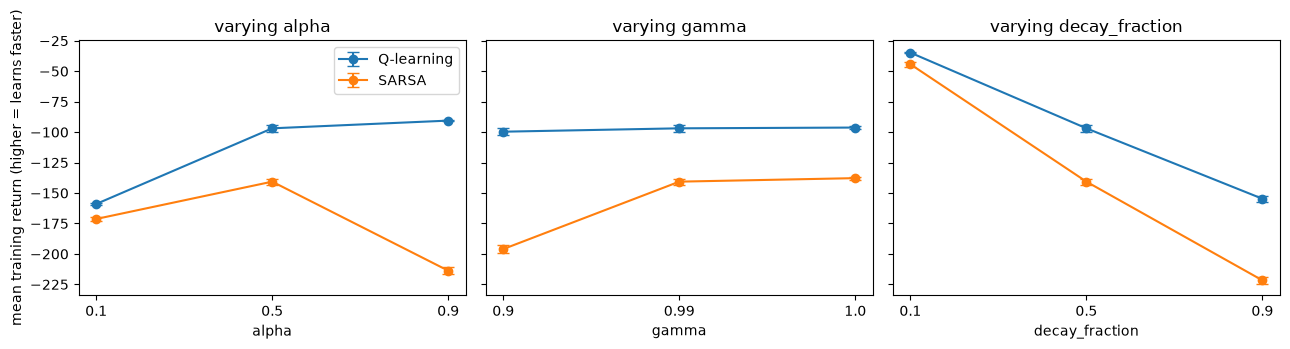

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, param in zip(axes, GRID):
    part = sensitivity[sensitivity.param == param]
    for algo_name in ALGORITHMS:
        agg = part[part.algorithm == algo_name].groupby("value")["mean_training_return"].agg(["mean", "std"])
        ax.errorbar(agg.index.astype(str), agg["mean"], yerr=agg["std"], marker="o", capsize=4, label=algo_name)
    ax.set(title=f"varying {param}", xlabel=param)
axes[0].set_ylabel("mean training return (higher = learns faster)")
axes[0].legend()
plt.tight_layout()
plt.show()

In [49]:
for param in GRID:
    part = sensitivity[sensitivity.param == param].groupby(["value"])[["mean_training_return", "greedy_return"]].mean()
    best_value = part["mean_training_return"].idxmax()
    spread = part["mean_training_return"].max() - part["mean_training_return"].min()
    print(f"{param:15s}: best value by training return = {best_value} | spread across values = {spread:6.1f} "
          f"| greedy return range {part['greedy_return'].min():6.2f} … {part['greedy_return'].max():6.2f}")

most_sensitive = max(GRID, key=lambda p: np.ptp(sensitivity[sensitivity.param == p].groupby("value")["mean_training_return"].mean()))
print(f"\n→ Most sensitive hyperparameter on Taxi (by training-return spread): {most_sensitive}")

# pick the configuration with the best mean training return among configs whose greedy policy is near the best
config_scores = sensitivity.groupby(["param", "value"])[["greedy_return", "mean_training_return"]].mean()
good = config_scores[config_scores["greedy_return"] >= config_scores["greedy_return"].max() - 0.5]
best_param, best_value = good["mean_training_return"].idxmax()
CHOSEN = {**BASE, best_param: float(best_value)}
print(f"→ Chosen configuration (from tuning seeds only): {CHOSEN}")

alpha          : best value by training return = 0.5 | spread across values =   46.4 | greedy return range -192.82 …   7.37
gamma          : best value by training return = 1.0 | spread across values =   30.8 | greedy return range -22.12 …   7.37
decay_fraction : best value by training return = 0.1 | spread across values =  148.7 | greedy return range  -2.64 …   7.37

→ Most sensitive hyperparameter on Taxi (by training-return spread): decay_fraction
→ Chosen configuration (from tuning seeds only): {'alpha': 0.5, 'gamma': 0.99, 'decay_fraction': 0.5}


### Step 3 — Final comparison on fresh seeds with learning curves

final runs took 10 s


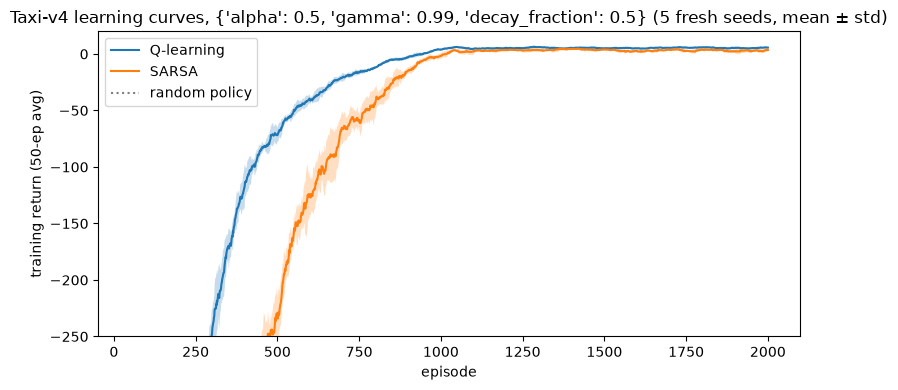

In [50]:
FINAL_SEEDS, FINAL_EVAL_OFFSET = [100, 101, 102, 103, 104], 50_000
final_curves, final_scores = {}, {}
start = time.perf_counter()
for algo_name, algo in ALGORITHMS.items():
    curves, scores = [], []
    for seed in FINAL_SEEDS:
        Q_run, training_returns = algo(taxi, N_EPISODES, eps_start=1.0, eps_end=0.05, seed=seed, **CHOSEN)
        curves.append(training_returns)
        scores.append(run_policy(taxi, Q_run.argmax(1), 200, seed=FINAL_EVAL_OFFSET + seed).mean())
    final_curves[algo_name], final_scores[algo_name] = np.stack(curves), np.array(scores)
print(f"final runs took {time.perf_counter() - start:.0f} s")

fig, ax = plt.subplots(figsize=(8, 4))
smooth = 50
for algo_name, curves in final_curves.items():
    smoothed = np.stack([np.convolve(c, np.ones(smooth) / smooth, mode="valid") for c in curves])
    x = np.arange(smoothed.shape[1]) + smooth
    ax.plot(x, smoothed.mean(0), label=algo_name)
    ax.fill_between(x, smoothed.mean(0) - smoothed.std(0), smoothed.mean(0) + smoothed.std(0), alpha=0.25)
ax.axhline(random_taxi.mean(), ls=":", c="gray", label="random policy")
ax.set(xlabel="episode", ylabel=f"training return ({smooth}-ep avg)", ylim=(-250, 20),
       title=f"Taxi-v4 learning curves, {CHOSEN} (5 fresh seeds, mean ± std)")
ax.legend()
plt.tight_layout()
plt.show()

### Step 4 — Results table and computed conclusions

In [51]:
def episodes_to_reach(curves, threshold, smooth=50):
    """First episode where the smoothed training return reaches `threshold` (per seed)."""
    out = []
    for c in curves:
        sm = np.convolve(c, np.ones(smooth) / smooth, mode="valid")
        hit = np.flatnonzero(sm >= threshold)
        out.append(hit[0] + smooth if len(hit) else np.nan)
    return np.array(out, dtype=float)


results = pd.DataFrame({
    algo_name: {
        "greedy return (mean)": final_scores[algo_name].mean(),
        "greedy return (std over seeds)": final_scores[algo_name].std(ddof=1),
        "seeds with a working policy (return > 0)": int((final_scores[algo_name] > 0).sum()),
        "mean training return": final_curves[algo_name].mean(),
        "episodes to reach 0 (mean)": np.nanmean(episodes_to_reach(final_curves[algo_name], 0.0)),
    }
    for algo_name in ALGORITHMS
}).T.round(2)
results

,greedy return (mean),greedy return (std over seeds),seeds with a working policy (return > 0),mean training return,episodes to reach 0 (mean)
Q-learning,7.89,0.22,5.0,-94.05,934.2
SARSA,-45.87,111.76,3.0,-139.90,997.2


In [52]:
q_scores, s_scores = final_scores["Q-learning"], final_scores["SARSA"]
t_stat, p_value = stats.ttest_ind(q_scores, s_scores, equal_var=False)
print(f"greedy return — Q-learning {q_scores.mean():.2f} ± {q_scores.std(ddof=1):.2f} | SARSA {s_scores.mean():.2f} ± {s_scores.std(ddof=1):.2f}")
print(f"Welch t-test p = {p_value:.3f} →",
      "a statistically clear difference in final policy quality" if p_value < 0.05
      else "no statistically clear difference in final policy quality with 5 seeds")
for algo_name, scores in final_scores.items():
    n_ok = int((scores > 0).sum())
    note = "" if n_ok == len(scores) else f" — {len(scores) - n_ok} seed(s) had not learned to deliver the passenger, which inflates the std"
    print(f"{algo_name}: {n_ok}/{len(scores)} seeds learned a working greedy policy{note}")
most_reliable = max(final_scores, key=lambda k: ((final_scores[k] > 0).sum(), -final_scores[k].std()))
print(f"→ With this budget, {most_reliable} is the more reliable choice on Taxi (more seeds solved, lower spread).")

faster = results["episodes to reach 0 (mean)"].idxmin()
more_reward = results["mean training return"].idxmax()
print(f"{faster} reaches a non-negative training return sooner "
      f"({results.loc[faster, 'episodes to reach 0 (mean)']:.0f} vs "
      f"{results['episodes to reach 0 (mean)'].max():.0f} episodes).")
print(f"{more_reward} collects more reward during training "
      f"({results.loc[more_reward, 'mean training return']:.1f} vs {results['mean training return'].min():.1f}).")
print(f"Both beat the random policy ({random_taxi.mean():.0f}) by more than "
      f"{min(q_scores.mean(), s_scores.mean()) - random_taxi.mean():.0f} return points.")

greedy return — Q-learning 7.89 ± 0.22 | SARSA -45.87 ± 111.76
Welch t-test p = 0.343 → no statistically clear difference in final policy quality with 5 seeds
Q-learning: 5/5 seeds learned a working greedy policy
SARSA: 3/5 seeds learned a working greedy policy — 2 seed(s) had not learned to deliver the passenger, which inflates the std
→ With this budget, Q-learning is the more reliable choice on Taxi (more seeds solved, lower spread).
Q-learning reaches a non-negative training return sooner (934 vs 997 episodes).
Q-learning collects more reward during training (-94.0 vs -139.9).
Both beat the random policy (-769) by more than 723 return points.


**Stretch goals**
1. Add **Expected SARSA** (target uses the ε-greedy *average* of $Q(s', \cdot)$) and **Double Q-learning** from Exercise 6 to the comparison.
2. Turn on `gym.make("Taxi-v4", is_rainy=True, fickle_passenger=True)` — the stochastic version from Dietterich's paper. Does SARSA's caution help now?
3. Replace ε-greedy with **optimistic initial values** (`Q = np.full(..., 10.0)`, ε = 0). Is exploration still needed?
4. Vary α **jointly** with the decay schedule (a small grid) instead of one-at-a-time — do interactions change the choice?

### 🗣️ How to talk about this in an interview
- "I implemented tabular Q-learning and SARSA from scratch and compared them on Taxi-v4 over 5 seeds, reporting learning curves with mean ± std bands and greedy evaluation over 200 episodes per seed."
- "I tuned α, γ, and the ε-decay fraction one at a time on **tuning seeds**, then re-ran the chosen config on **fresh training and evaluation seeds** — the RL version of not touching the test set."
- "I separated *sample efficiency* (area under the training curve) from *final policy quality* (greedy return), because they can disagree — exploration hurts training return but not the greedy policy."
- "The environment returns `terminated` and `truncated` separately; I bootstrap on the 200-step truncation and not on real drop-offs."
- "Next I'd move to function approximation (DQN) because tables don't scale beyond a few thousand states."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What is the exploration–exploitation trade-off, and how do you handle it?**

<details><summary>Show answer</summary>

- **30-second answer:** The agent must *exploit* what it believes is best to earn reward, but also *explore* to discover whether something better exists. The simplest fix is ε-greedy with a decaying ε; smarter options are UCB, Thompson sampling, optimistic initial values, and (in deep RL) an entropy bonus.
- **Go deeper:** Pure greedy can lock onto a suboptimal action forever (Section 7: ε = 0 found the best arm far less often). Exploration cost is real in production — that's why online systems often use bandits with principled exploration, or learn offline from logged data.
- **❌ Common wrong answer:** "Explore at the start, then stop completely" without a schedule or justification — or "just set ε = 0.5".

</details>

**Q2. What's the difference between on-policy and off-policy learning?**

<details><summary>Show answer</summary>

- **30-second answer:** On-policy methods learn the value of the policy that is generating the data (SARSA, A2C, PPO). Off-policy methods learn about a *different* target policy — usually the greedy one — from data collected by a behaviour policy (Q-learning, DQN, SAC), which lets them reuse old experience from a replay buffer.
- **Go deeper:** Q-learning's target uses $\max_{a'} Q(s',a')$, ignoring what the exploring agent will actually do; SARSA's uses $Q(s', a')$ for the action actually taken. Off-policy is more sample-efficient but can be less stable with function approximation (the "deadly triad": function approximation + bootstrapping + off-policy).
- **❌ Common wrong answer:** "Off-policy means offline." Offline RL learns from a fixed dataset with no interaction; off-policy algorithms usually still interact with the environment.

</details>

**Q3. Write the Bellman expectation and optimality equations. What's the difference?**

<details><summary>Show answer</summary>

- **30-second answer:** Expectation: $V^\pi(s) = \sum_a \pi(a|s) \sum_{s',r} p(s',r|s,a)[r + \gamma V^\pi(s')]$ — the value of following a fixed policy. Optimality: $V^*(s) = \max_a \sum_{s',r} p(s',r|s,a)[r + \gamma V^*(s')]$ — the value of acting optimally. The first is linear (solve with linear algebra), the second has a max (solve with value/policy iteration).
- **Go deeper:** The Bellman backup is a γ-contraction in the max norm, which is why value iteration converges from any starting point. TD learning and Q-learning are *sampled* versions of these backups.
- **❌ Common wrong answer:** Forgetting the expectation over next states (writing it as if the environment were deterministic), or forgetting that terminal states have no future value.

</details>

**Q4. What does the discount factor γ mean, and how do you choose it?**

<details><summary>Show answer</summary>

- **30-second answer:** γ ∈ [0, 1] weights future rewards: reward $k$ steps ahead counts $\gamma^k$. It keeps infinite returns finite and sets an effective horizon of about $1/(1-\gamma)$. Choose it so the horizon covers how far ahead consequences matter (γ = 0.99 ≈ 100 steps).
- **Go deeper:** Higher γ is more far-sighted but increases variance and slows learning; too low makes the agent myopic (Section 3). It can also be viewed as a per-step probability that the episode continues. In the Taxi project, γ changed results noticeably.
- **❌ Common wrong answer:** "γ is the learning rate" (that's α) or "higher γ is always better".

</details>

**Q5. Model-based vs model-free RL?**

<details><summary>Show answer</summary>

- **30-second answer:** Model-based methods use (or learn) the transition and reward model and **plan** with it — value iteration, MCTS, Dyna, MuZero, Dreamer. Model-free methods learn a value function or policy directly from experience — Q-learning, SARSA, PPO.
- **Go deeper:** Model-based is usually far more sample-efficient but suffers from *model bias* (planning exploits the model's mistakes). Model-free is simpler and asymptotically strong but needs lots of interaction. Our Build It From Scratch showed both reaching the same optimal values on FrozenLake.
- **❌ Common wrong answer:** "Model-based means it uses a neural network model." The "model" means a model of the *environment dynamics*, not the policy network.

</details>

**Q6. Value-based vs policy-based methods — when would you pick each?**

<details><summary>Show answer</summary>

- **30-second answer:** Value-based methods learn Q and act greedily (Q-learning, DQN) — great for discrete actions and sample-efficient off-policy learning. Policy-based methods parameterise the policy directly and follow the gradient of expected return (REINFORCE, PPO) — natural for continuous actions and stochastic policies. Actor-critic methods combine both.
- **Go deeper:** Taking $\max_a Q$ over a continuous action space is itself an optimisation problem, which is why continuous control uses actor-critics (DDPG/TD3/SAC). Policy gradients are on-policy and high-variance, so they need baselines/advantages — covered in the next notebook.
- **❌ Common wrong answer:** "Policy-based methods don't use value functions." Almost all practical ones (A2C, PPO) learn a value function as a critic/baseline.

</details>

**Q7. Compare Monte Carlo and temporal-difference learning.**

<details><summary>Show answer</summary>

- **30-second answer:** MC updates toward the full observed return — unbiased but high variance, and it must wait for the episode to end. TD updates toward $r + \gamma V(s')$ after every step — biased because it bootstraps, but lower variance and works for continuing tasks.
- **Go deeper:** n-step returns and TD(λ) interpolate between the two; PPO's GAE is the same idea applied to advantages. With a constant learning rate, TD keeps fluctuating around the answer (Section 6).
- **❌ Common wrong answer:** "TD is always better because it's faster" — it trades variance for bias, and the bias can hurt with poor value estimates.

</details>

### 💻 Coding

**Q8. Write the tabular Q-learning update inside an episode loop using the Gymnasium API.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  obs, reward, terminated, truncated, info = env.step(action)
  target = reward + gamma * Q[obs].max() * (not terminated)
  Q[state, action] += alpha * (target - Q[state, action])
  state, done = obs, terminated or truncated
  ```
- **Go deeper:** Choose actions ε-greedily with **random tie-breaking**; seed `reset` once and seed the action space; evaluate the greedy policy separately. For convergence to $Q^*$ every pair must be visited infinitely often with a decaying α.
- **❌ Common wrong answer:** `target = reward + gamma * Q[obs].max() * (not (terminated or truncated))` — it treats time-outs as terminal.

</details>

**Q9. Implement value iteration for a known MDP. What's the complexity per sweep?**

<details><summary>Show answer</summary>

- **30-second answer:** Repeat until convergence: `Q = R + gamma * T @ V; V = Q.max(axis=1)`, where `T[s,a,s']` holds transition probabilities (zero for terminal transitions) and `R[s,a]` expected rewards. Extract the policy with `Q.argmax(axis=1)`.
- **Go deeper:** Each sweep costs $O(|S|^2 |A|)$ with a dense model (less with sparse transitions). The error shrinks by a factor γ per sweep, so reaching tolerance ε takes about $\log(1/\varepsilon) / \log(1/\gamma)$ sweeps — many when γ is close to 1. Policy iteration needs fewer but more expensive iterations.
- **❌ Common wrong answer:** Updating the policy inside the sweep without a max, or bootstrapping from terminal states.

</details>

### 🐛 Debugging Scenarios

**Q10. On CliffWalking, your Q-learning agent's training returns are much worse than your teammate's SARSA agent, yet its greedy path is shorter. Is Q-learning broken?**

<details><summary>Show answer</summary>

- **30-second answer:** No — this is expected. Q-learning learns the optimal greedy path along the cliff edge, but with ε-greedy exploration it occasionally steps off (−100) during training. SARSA learns the value of its exploring policy, so it takes a safer, longer path and earns more while training.
- **Go deeper:** Evaluate both greedily and they rank the other way (−13 vs about −17). Decaying ε to zero makes both converge to the optimal path. Choose SARSA-style on-policy learning when mistakes during training are costly.
- **❌ Common wrong answer:** "SARSA is just a better algorithm" — it depends on whether you care about performance *during* learning or the final greedy policy.

</details>

**Q11. Your agent learns well at first, but values of late-episode states stay too low, and it prefers to end episodes early. What do you check?**

<details><summary>Show answer</summary>

- **30-second answer:** Check whether time-limit truncations are treated as terminal. Using `done = terminated or truncated` in the target sets future value to zero at time-outs, biasing values down — Section 12 showed it flipping the optimal policy from "stay" to "quit".
- **Go deeper:** Bootstrap on truncation: `target = r + γ·V(s')·(1 − terminated)`. Alternatively add the remaining time to the observation (`TimeAwareObservation`) if the time limit is really part of the task. Libraries like SB3 handle this via `terminal_observation` in `info`.
- **❌ Common wrong answer:** "Increase γ" or "train longer" — neither fixes a wrong target.

</details>

**Q12. You added a shaping reward for "getting closer to the goal" and now the agent never finishes the task. Why?**

<details><summary>Show answer</summary>

- **30-second answer:** The shaping created a reward loop — it pays to move closer, costs nothing to move away, so oscillating forever earns more than finishing. This is **reward hacking**: the agent optimises the reward you wrote, not the goal you meant.
- **Go deeper:** Use **potential-based shaping** $F = \gamma\Phi(s') - \Phi(s)$ (Ng, Harada & Russell, 1999), which telescopes over a trajectory and provably keeps the optimal policy. Always evaluate with the *true* task metric, not the shaped reward. The same failure appears in RLHF, where policies exploit reward-model weaknesses.
- **❌ Common wrong answer:** "Make the shaping reward smaller" — a smaller loop is still a loop if the episode is long enough.

</details>

### 🏗️ Design

**Q13. How would you evaluate and report an RL agent so that stakeholders can trust the result?**

<details><summary>Show answer</summary>

- **30-second answer:** Evaluate the greedy (deterministic) policy on separate evaluation environments with different seeds, over many episodes; train with multiple seeds (≥ 5 if affordable); report mean ± std or confidence intervals, learning curves, and a simple baseline; keep tuning seeds separate from final seeds.
- **Go deeper:** Report both sample efficiency (area under the curve) and final performance; use statistical tests or bootstrap CIs across seeds (Henderson et al., 2018; Agarwal et al., 2021 recommend interquartile mean with CIs). For production, add safety metrics and off-policy evaluation on logged data before deploying.
- **❌ Common wrong answer:** "Show the best training curve" or evaluate a single episode with exploration still on.

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal.

**1.** `discounted_return([1, 1, 1], gamma=0.5)`
<details><summary>Answer</summary>

`1.75` — $1 + 0.5 + 0.25$.
</details>

**2.** In Gymnasium 1.x, how many values does `env.step(action)` return, and how many does `env.reset()` return?
<details><summary>Answer</summary>

`step` → 5: `(obs, reward, terminated, truncated, info)`. `reset` → 2: `(obs, info)`.
</details>

**3.** For `CartPole-v1`, what is the time limit and at what pole angle does the episode terminate?
<details><summary>Answer</summary>

500 steps (then `truncated=True`), and |angle| > 12° (or the cart leaves ±2.4) gives `terminated=True` — both read directly from the environment in Section 1.
</details>

**4.** A transition has $r = -1$, $\gamma = 0.9$, $\max_{a'} Q(s', a') = 10$, `terminated=False`, `truncated=True`. What is the Q-learning target?
<details><summary>Answer</summary>

`8.0` — truncation still bootstraps: $-1 + 0.9 \times 10$.
</details>

**5.** With a constant ε = 0.1 on CliffWalking, which algorithm earns more reward **during training**, and which greedy path is shorter?
<details><summary>Answer</summary>

SARSA earns more during training (safer path); Q-learning's greedy path is shorter (along the cliff edge).
</details>

## 📚 Resources

### 📖 Official Docs
- [Gymnasium — Basic Usage](https://gymnasium.farama.org/introduction/basic_usage/) — the reset/step loop, spaces, and wrappers from the maintainers
- [Gymnasium — Handling Time Limits](https://gymnasium.farama.org/tutorials/gymnasium_basics/handling_time_limits/) — the official explanation of terminated vs truncated
- [Gymnasium — Create a Custom Environment](https://gymnasium.farama.org/introduction/create_custom_env/) — the full custom-environment tutorial
- [Gymnasium — Wrappers](https://gymnasium.farama.org/api/wrappers/) — every built-in wrapper
- [Toy Text environments](https://gymnasium.farama.org/environments/toy_text/) — FrozenLake, CliffWalking, Taxi, Blackjack reference pages

### 🎥 Videos
- [Google DeepMind (David Silver) — RL Course Lecture 1: Introduction to Reinforcement Learning](https://www.youtube.com/watch?v=2pWv7GOvuf0) (1 h 28 min) — the classic first lecture on agents, rewards, and MDPs; watch after Section 4
- [Google DeepMind (David Silver) — RL Course Lecture 3: Planning by Dynamic Programming](https://www.youtube.com/watch?v=Nd1-UUMVfz4) (1 h 39 min) — policy evaluation, policy iteration, and value iteration in depth
- [Mutual Information — Reinforcement Learning, by the Book](https://www.youtube.com/watch?v=NFo9v_yKQXA) (18 min) — a crisp visual summary of Sutton & Barto's core ideas; great as a review before an interview

### 📄 Papers
- [Watkins & Dayan (1992) — Q-learning](https://link.springer.com/article/10.1007/BF00992698) — the convergence proof for Q-learning
- [Pardo et al. (2018) — Time Limits in Reinforcement Learning](https://arxiv.org/abs/1712.00378) — why you bootstrap on time-outs (Section 12)
- [van Hasselt et al. (2015) — Deep Reinforcement Learning with Double Q-learning](https://arxiv.org/abs/1509.06461) — maximisation bias and the double estimator (Exercise 6)
- [Henderson et al. (2018) — Deep Reinforcement Learning that Matters](https://arxiv.org/abs/1709.06560) — seeds, variance, and honest evaluation

### 📘 Books & Courses
- [Sutton & Barto — Reinforcement Learning: An Introduction (2nd ed., free online)](http://incompleteideas.net/book/the-book-2nd.html) — *the* RL textbook; Chapters 3–6 match this notebook
- [Hugging Face Deep RL Course — Unit 2: Introduction to Q-Learning](https://huggingface.co/learn/deep-rl-course/unit2/introduction) — free, hands-on, with FrozenLake and Taxi
- [OpenAI Spinning Up — Part 1: Key Concepts in RL](https://spinningup.openai.com/en/latest/spinningup/rl_intro.html) — concise definitions and notation used across deep RL papers

### 🏋️ Practice
- Solve `FrozenLake8x8-v1` (slippery) with both value iteration and Q-learning, and compare success rates over 5 seeds.
- [Hugging Face Deep RL Course](https://huggingface.co/learn/deep-rl-course/unit0/introduction) — each unit ends with a hands-on notebook you can push to a public leaderboard

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| RL loop | agent acts, environment returns next state + reward | `obs, info = env.reset(seed=s)`; `obs, r, terminated, truncated, info = env.step(a)` |
| Spaces | define valid observations/actions | `Discrete(n)`, `Box(low, high, shape)`, `Dict`, `.sample()`, `.contains()` |
| Return | discounted sum of future rewards | $G_t = \sum_k \gamma^k r_{t+k+1}$; horizon ≈ $1/(1-\gamma)$ |
| Bellman expectation | value of a fixed policy | $V^\pi(s) = \sum_a \pi(a \mid s) \sum p\,[r + \gamma V^\pi(s')]$ |
| Bellman optimality | value of the best policy | $V^*(s) = \max_a \sum p\,[r + \gamma V^*(s')]$ |
| Value / policy iteration | plan with a known model | `Q = R + γ T @ V; V = Q.max(1)` · evaluate ↔ improve |
| Monte Carlo vs TD | learn values from experience | MC target $G_t$ (unbiased) · TD target $r + \gamma V(s')$ (low variance) |
| ε-greedy | balance exploration and exploitation | random with prob. ε, else argmax with random ties; decay ε |
| Q-learning (off-policy) | learn $Q^*$ | $Q \leftarrow Q + \alpha[r + \gamma \max_{a'} Q(s',a') - Q]$ |
| SARSA (on-policy) | learn $Q^\pi$ of the ε-greedy policy | $Q \leftarrow Q + \alpha[r + \gamma Q(s',a') - Q]$ |
| Terminated vs truncated | when to bootstrap | multiply future term by `(not terminated)` — **never** by `(not truncated)` |
| Wrappers | modify an env without editing it | `TimeLimit`, `RecordEpisodeStatistics`, `ObservationWrapper`, `RewardWrapper` |
| Custom env | your problem as an MDP | subclass `gym.Env`, `super().reset(seed=seed)`, `check_env`, `gym.register` |
| Evaluation | trustworthy numbers | greedy policy, many episodes, ≥ 3–5 seeds, mean ± std, separate eval seeds |

## ➡️ What's Next

**[02 · Deep RL with Stable-Baselines3](02_Deep_RL_with_Stable_Baselines3.ipynb)** — tables stop working once states are continuous (CartPole's 4 real numbers) or huge (images). Next you'll replace the Q-table with a neural network (DQN), learn policies directly with policy gradients (REINFORCE, PPO), use Stable-Baselines3 correctly, and see how the same ideas power RLHF for LLMs.